# 35 · Diffusion 역과정: 잡음 예측으로 $T$걸음 되돌리기, DDIM, 조건부 생성

**이번 질문:** 34번에서 배운 $\hat\epsilon$ 하나로 순수 잡음 $x_T$에서 $x_0$까지 어떻게 돌아올까요? 200걸음을 10걸음으로 줄일 수 있을까요? 그리고 "7을 그려라"처럼 원하는 것을 지정할 수 있을까요?

34번은 데이터를 지우는 **전방 과정**과, 그 과정에서 더한 잡음 $\epsilon$을 맞히는 신경망을 만들었습니다. 지우는 쪽은 끝났고 이제 되돌리는 쪽입니다.
되돌리기의 한 걸음은 새 수식이 아닙니다. 34번 2절의 되묻기 $q(x_{t-1}\mid x_t,x_0)$에서 우리가 모르는 $x_0$ 자리에 **예측한 $\hat x_0$를 넣으면** 그대로 역과정이 됩니다. 그 걸음을 $T$번 반복하면 잡음 하나가 그림 하나가 됩니다.
한 걸음 → 전체 루프와 학습한 모델 → 걸음을 건너뛰는 DDIM → 원하는 숫자를 지정하는 조건부 생성과 guidance 순서로 갑니다.

- 준비물: [34](34_diffusion_forward.ipynb)의 스케줄·닫힌식 $q(x_t\mid x_0)$·posterior 계수·잡음 예측 신경망(본문에 짧게 다시 정의하고 다시 학습합니다), [23](23_latent_mixture_em.ipynb)의 혼합과 `mix_denoiser`, [33](33_ncsn.ipynb)의 Langevin 사다리, [12](../02_연결/12_gaussian_information.ipynb)의 Gaussian, [09](../01_아키텍처/09_transformer.ipynb) 4절의 sinusoidal 표.
- 도착점: DDPM 역과정·DDIM·classifier-free guidance를 손계산과 닫힌식 최적 $\epsilon$으로 검산하고, 1차원·2차원 혼합과 MNIST PCA-32 좌표에서 실제로 샘플을 만듭니다.
- 다음 연결: [35b EDM](35b_edm.ipynb)은 지금까지의 스케줄·가중치·sampler 선택을 하나의 틀로 정리합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 역과정 한 걸음은 $p_\theta(x_{t-1}\mid x_t)=\mathcal N(\mu_\theta,\sigma_t^2I)$이고 $\mu_\theta=\frac{1}{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\hat\epsilon\right)$입니다. 이는 34번 2절의 posterior 평균에 $\hat x_0$를 넣은 것과 **정확히 같습니다.** 코드로는 `(x_t - beta[t] / np.sqrt(1 - alpha_bar[t]) * eps_hat) / np.sqrt(1 - beta[t])`.
2. DDIM은 같은 $\hat\epsilon$으로 $x_{t-1}=\sqrt{\bar\alpha_{t-1}}\,\hat x_0+\sqrt{1-\bar\alpha_{t-1}}\,\hat\epsilon$을 걷습니다. 잡음이 없으니 **결정적**이고, 이웃한 시각이 아니라 건너뛴 시각으로도 걸을 수 있어 200걸음을 10걸음으로 줄입니다.
3. label을 입력에 이어 붙여 학습하되 확률 $p_{\text{uncond}}$로 label을 비우면, 샘플링에서 $\tilde\epsilon=(1+w)\,\hat\epsilon(x_t,t,y)-w\,\hat\epsilon(x_t,t,\varnothing)$로 조건을 강조할 수 있습니다. 코드로는 `(1 + w) * eps_cond - w * eps_null`.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/diffusion_reverse_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(2절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/diffusion_reverse_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist
from src.utils.diffusion_reverse_plots import (
    plot_curves, plot_reverse_step, plot_reverse_histograms, plot_reverse_paths, plot_samples_2d,
    plot_sample_grid, plot_snapshot_strip, plot_ddim_paths, plot_image_rows, plot_guidance_concept,
    plot_sampler_comparison,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· diffusion 역과정 준비 완료")

NumPy 2.4.6 · diffusion 역과정 준비 완료


### 📎 이 노트북의 예시: 1차원·2차원 두 봉우리 혼합, MNIST PCA-32 좌표와 숫자 label

- **1차원·2차원 두 봉우리 혼합.** 23번부터 쓰는 공통 상황입니다. 비율 $\pi=(0.3,0.7)$, 평균 $\mu=(-2,2)$, 표준편차 $\sigma=(0.5,1)$인 두 Gaussian을 섞은 분포입니다. 정답 $\epsilon$을 닫힌식으로 알 수 있어, **신경망 자리에 정답을 끼워 넣고** 역과정 자체가 맞는지 먼저 확인할 수 있습니다.
- **MNIST PCA-32 좌표.** 앞 5,000장을 11번 3절의 고유분해로 32차원 좌표로 줄인 것입니다(34번과 같은 규약). 2절에서 이 좌표 위의 잡음 예측 신경망을 학습해 숫자 그림을 만들고, 4절에서는 **숫자 label을 함께** 줍니다.
- **숫자 label $y$.** 앞 5,000장의 정답 숫자 0–9입니다. 4절에서 "이 숫자를 그려라"라고 지정하는 조건으로 씁니다.

> **용어**
>
> - **역과정(reverse process)** $p_\theta$: 잡음 $x_T$에서 데이터 $x_0$ 쪽으로 한 걸음씩 되돌아오는 **학습된** 규칙. 전방 과정 $q$는 고정이고, 학습하는 것은 이쪽뿐입니다 (34번 1절).
> - **sampler**: 역과정을 실제로 몇 걸음, 어떤 식으로 걸을지 정한 절차. 같은 모델이라도 sampler를 바꾸면 결과와 비용이 달라집니다. DDPM과 DDIM이 이 노트북의 두 sampler입니다.
> - **혼합(mixture) 분포**: 성분 $k$를 비율 $\pi_k$로 고른 뒤 그 Gaussian에서 점을 뽑는 분포 (23번 1절). **책임확률(responsibility)** $r_k(x)$는 점 $x$가 성분 $k$에서 왔을 확률입니다 (23번 2절).
> - **MNIST**: 28×28 흑백 손글씨 숫자 이미지 데이터셋. 여기서는 "잡음에서 출발해 숫자 그림이 만들어지는가"를 눈으로 보려고 씁니다.

아래 다섯 셀은 실행만 하고 넘어가도 됩니다. 혼합 함수는 23번의 정의를, 전방 과정은 34번의 정의를 짧게 다시 쓴 것입니다.

> **코드**
>
> - `x[:, None]`: `(N,)`을 `(N, 1)`로 세워 `(2,)`짜리 성분 배열과 브로드캐스팅. 결과는 `(N, 2)` = 점마다 성분 두 개.
> - `terms.max(axis=1, keepdims=True)`: 행마다 최댓값을 `(N, 1)`로 남겨 빼기 쉽게 합니다. 지수가 넘치지 않게 하는 02번 8절의 안정화입니다.
> - `rng.choice(2, size=n, p=MIX_PI)`: 0 또는 1을 확률 `MIX_PI`로 n번 뽑습니다. 잠재 성분 $z$를 먼저 뽑는 ancestral sampling (23번 5절).
> - `np.linalg.solve(C, d.T).T`: 관측마다 $C^{-1}d$를 한 번에 (12번 2절). `np.linalg.slogdet(C)[1]`은 $\log\det C$.

In [2]:
MIX_PI = np.array([0.3, 0.7])                                        # (2,): 성분 비율 π_k
MIX_MU = np.array([-2.0, 2.0])                                       # (2,): 성분 평균 μ_k
MIX_SIGMA = np.array([0.5, 1.0])                                     # (2,): 성분 표준편차 σ_k
MIX2_PI = np.array([0.4, 0.6])                                       # (2,): 2차원 혼합의 비율
MIX2_MU = np.array([[-2.0, 0.0], [2.0, 1.0]])                        # (2, 2): 성분 평균 (행 = 성분)
MIX2_COV = np.array([[[0.6, 0.2], [0.2, 0.5]], [[0.4, -0.1], [-0.1, 0.8]]])   # (2, 2, 2): 성분 공분산 Σ_k
print("1차원 π, μ, σ:", MIX_PI, MIX_MU, MIX_SIGMA, "· 2차원 평균", MIX2_MU.tolist())

1차원 π, μ, σ: [0.3 0.7] [-2.  2.] [0.5 1. ] · 2차원 평균 [[-2.0, 0.0], [2.0, 1.0]]


In [3]:
def mix_log_terms(x, sigma=0.0):
    """성분별 log π_k + log N(x; μ_k, σ_k² + σ²). sigma 는 나중에 더하는 잡음의 표준편차(0이면 원래 혼합). x: (N,) → (N, 2)."""
    variances = MIX_SIGMA ** 2 + sigma ** 2                          # (2,): 성분 분산
    squared = (x[:, None] - MIX_MU) ** 2 / variances                 # (N, 2): 표준화한 제곱 거리
    return np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * variances) + squared)


def mix_logpdf(x, sigma=0.0):
    """23번 1절: log p(x) = logsumexp_k [log π_k + log N(x; μ_k, σ_k²)]. x: (N,) → (N,)."""
    terms = mix_log_terms(x, sigma)
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값 (안정화)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix_responsibility(x, sigma=0.0):
    """23번 2절: r_k(x) = softmax_k 로그 항. x: (N,) → (N, 2), 행 합 1."""
    terms = mix_log_terms(x, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, 2)
    return shifted / shifted.sum(axis=1, keepdims=True)

In [4]:
def mix_sample(n, rng):
    """23번 5절 ancestral sampling: z ~ π 를 뽑고 x ~ N(μ_z, σ_z²). n: 개수 → (n,)."""
    z = rng.choice(2, size=n, p=MIX_PI)                              # (n,): 성분 번호
    return MIX_MU[z] + MIX_SIGMA[z] * rng.normal(size=n)


def mix_denoiser(x_noisy, sigma):
    """23번 5절: 잡음 뒤 최적 복원 E[x₀ | x̃] = Σ_k r_k^σ(x̃) [μ_k + σ_k²/(σ_k² + σ²) (x̃ − μ_k)]. x_noisy: (N,) → (N,)."""
    r = mix_responsibility(x_noisy, sigma)                           # (N, 2): 분산 σ_k² + σ² 의 책임확률
    shrink = MIX_SIGMA ** 2 / (MIX_SIGMA ** 2 + sigma ** 2)          # (2,): 성분별로 x̃ 를 μ_k 쪽으로 당기는 비율
    return np.sum(r * (MIX_MU + shrink * (x_noisy[:, None] - MIX_MU)), axis=1)

In [5]:
def mix2_log_terms(X, sigma=0.0):
    """2차원 성분별 log π_k + log N(x; μ_k, Σ_k + σ²I). X: (N, 2) → (N, 2)."""
    terms = np.zeros((len(X), 2))
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)            # (2, 2): 잡음을 더한 공분산
        difference = X - MIX2_MU[k]                                  # (N, 2): x − μ_k
        squared = np.sum(difference * np.linalg.solve(covariance, difference.T).T, axis=1)   # (N,): (x−μ)ᵀ Σ⁻¹ (x−μ)
        terms[:, k] = np.log(MIX2_PI[k]) - 0.5 * (2 * np.log(2 * np.pi) + np.linalg.slogdet(covariance)[1] + squared)
    return terms


def mix2_logpdf(X, sigma=0.0):
    """2차원 혼합의 log p(x) (23번 1절). X: (N, 2) → (N,)."""
    terms = mix2_log_terms(X, sigma)
    biggest = terms.max(axis=1, keepdims=True)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix2_responsibility(X, sigma=0.0):
    """2차원 혼합의 책임확률 (23번 2절). X: (N, 2) → (N, 2)."""
    terms = mix2_log_terms(X, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))
    return shifted / shifted.sum(axis=1, keepdims=True)

In [6]:
def mix2_sample(n, rng):
    """2차원 ancestral sampling: z ~ π, x = μ_z + L_z ε (12번 1절의 Cholesky). n: 개수 → (n, 2)."""
    # 쓰는 것: MIX2_PI, MIX2_MU, MIX2_COV (📎 데이터 셀)
    z = rng.choice(2, size=n, p=MIX2_PI)                             # (n,)
    epsilon = rng.normal(size=(n, 2))                                # (n, 2): 독립 표준정규
    L = np.linalg.cholesky(MIX2_COV)                                 # (2, 2, 2): 성분마다 Σ_k = L_k L_kᵀ
    return MIX2_MU[z] + np.einsum("nij,nj->ni", L[z], epsilon)


def mix2_denoiser(X_noisy, sigma):
    """23번 5절의 2차원 판: E[x₀ | x̃] = Σ_k r_k^σ [μ_k + Σ_k (Σ_k + σ²I)⁻¹ (x̃ − μ_k)]. X_noisy: (N, 2) → (N, 2)."""
    # 쓰는 것: MIX2_MU, MIX2_COV (📎 데이터 셀)
    r = mix2_responsibility(X_noisy, sigma)                          # (N, 2)
    out = np.zeros_like(X_noisy)
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)
        pulled = (MIX2_COV[k] @ np.linalg.solve(covariance, (X_noisy - MIX2_MU[k]).T)).T   # (N, 2): 성분별 수축
        out += r[:, k:k + 1] * (MIX2_MU[k] + pulled)
    return out

📎 **참고** · 아래 두 셀은 MNIST를 읽고 앞 5,000장을 32차원 좌표로 줄입니다(34번과 같은 규약). 평균을 뺀 뒤 공분산의 고유벡터 상위 32개를 골라 그 방향의 좌표만 남기고, 마지막에 **전체 표준편차 하나**로 나누어 규모를 1 근처로 맞춥니다. `nearest_class`는 만든 샘플이 어느 숫자인지 **세기 위한** 도구이지 분류기가 아닙니다.

> **코드**
>
> - `np.linalg.eigh(C)`: 대칭 행렬의 고유값·고유벡터를 **오름차순**으로 돌려줍니다. `[:, ::-1]`로 열 순서를 뒤집어 큰 고유값부터 씁니다 (11번 3절).
> - `Z[:, None] - means[None]`: `(M, 1, 32)`와 `(1, 10, 32)`를 빼서 `(M, 10, 32)`. 샘플마다 클래스 평균 10개와의 차이를 한 번에 (00b번 3절).

In [7]:
mnist_X_all, mnist_y_all, mnist_X_test, mnist_y_test = load_mnist(download=True)
mnist_X = mnist_X_all[:5000]                                         # (5000, 784): 학습에 쓰는 앞 5,000장
mnist_y = mnist_y_all[:5000]                                         # (5000,): 그 정답 숫자 0–9
mnist_mu = mnist_X.mean(axis=0)                                      # (784,): 평균 이미지
mnist_centered = mnist_X - mnist_mu                                  # (5000, 784)
mnist_eigvals, mnist_eigvecs = np.linalg.eigh(mnist_centered.T @ mnist_centered / len(mnist_X))   # 공분산의 고유분해 (11번 3절)
mnist_Q = mnist_eigvecs[:, ::-1][:, :32]                             # (784, 32): 큰 고유값 32개의 방향
mnist_scale = float((mnist_centered @ mnist_Q).std())                # 숫자 하나: 좌표 전체의 표준편차
mnist_Z = (mnist_centered @ mnist_Q) / mnist_scale                   # (5000, 32): 규모를 1 근처로 맞춘 좌표
mnist_class_means = np.stack([mnist_Z[mnist_y == digit].mean(axis=0) for digit in range(10)])   # (10, 32): 숫자별 평균 좌표
mnist_norm = float(np.linalg.norm(mnist_Z, axis=1).mean())           # 데이터 좌표의 평균 길이 (샘플과 비교할 기준)
print("PCA 좌표", mnist_Z.shape, "· 전체 표준편차", round(mnist_scale, 4), "· 좌표의 평균 길이", round(mnist_norm, 3))

PCA 좌표 (5000, 32) · 전체 표준편차 1.1101 · 좌표의 평균 길이 5.589


In [8]:
def decode_pca(Z):
    """PCA-32 좌표를 28×28 이미지로 되돌립니다: X = (Z · scale) Qᵀ + μ. Z: (N, 32) → (N, 28, 28), 0–1로 자름."""
    # 쓰는 것: mnist_scale, mnist_Q, mnist_mu (📎 PCA 셀)
    flat = (Z * mnist_scale) @ mnist_Q.T + mnist_mu                  # (N, 784)
    return np.clip(flat, 0, 1).reshape(len(Z), 28, 28)


def nearest_class(Z):
    """좌표를 클래스 평균 최근접으로 숫자에 붙입니다 (00b번 5절). 분류기가 아니라 **세는 도구**입니다. Z: (N, 32) → (N,)."""
    # 쓰는 것: mnist_class_means (📎 PCA 셀)
    return np.argmin(np.sum((Z[:, None] - mnist_class_means[None]) ** 2, axis=2), axis=1)

📎 **참고** · 아래 세 셀은 34번의 전방 과정을 짧게 다시 씁니다. 스케줄 $\beta_t$, 닫힌식 $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$ (34번 1절), posterior 계수 $c_0,c_t,\tilde\beta_t$ (34번 2절), 혼합의 닫힌식 최적 $\epsilon$ (34번 3절)입니다.

**스케줄 하나만 34번과 다릅니다.** 34번은 $\beta$를 $10^{-4}$에서 $0.02$까지 키웠고 그 결과 $\bar\alpha_T=0.13$이 남았습니다. 신호가 3분의 1쯤 살아 있다는 뜻이라 $x_T$는 순수 잡음이 아니었습니다. 그런데 역과정은 **$x_T\sim\mathcal N(0,I)$에서 출발합니다.** 출발점이 어긋나면 되돌아온 분포도 어긋나므로, 이 노트북은 $\beta$를 $0.05$까지 키워 $\bar\alpha_T=0.006$으로 낮춥니다. 1-1절에서 두 스케줄을 실제로 비교합니다.

> **코드**
>
> - `np.cumprod(a)`: 누적곱 `[a₀, a₀a₁, a₀a₁a₂, …]`. $\bar\alpha_t=\prod_{s\le t}\alpha_s$가 정확히 이것입니다.
> - `alpha_bar[t - 1]`: 번호 0은 "아직 아무것도 더하지 않은 시각"이라 $\bar\alpha_0=1$입니다. 그래서 $t=1$에서도 $t-1$을 안전하게 쓸 수 있습니다.

In [9]:
T = 200                                                              # 걸음 수 (DDPM 논문은 1,000, 여기서는 실행 시간 때문에 200)
beta = np.concatenate([[0.0], np.linspace(1e-4, 0.05, T)])           # (201,): β_t. 번호 0 은 아직 더하지 않은 시각
alpha = 1 - beta                                                     # (201,): α_t = 1 − β_t
alpha_bar = np.cumprod(alpha)                                        # (201,): ᾱ_t = Π_{s≤t} α_s (누적곱)
beta_34 = np.concatenate([[0.0], np.linspace(1e-4, 0.02, T)])        # (201,): 34번이 쓴 스케줄 (1-1절 비교용)
alpha_bar_34 = np.cumprod(1 - beta_34)                               # (201,)
print("ᾱ_t at [0, 50, 100, 150, 200] =", alpha_bar[[0, 50, 100, 150, 200]].round(4))
print("ᾱ_T =", round(float(alpha_bar[T]), 5), "· √ᾱ_T =", round(float(np.sqrt(alpha_bar[T])), 4),
      "· 34번 스케줄의 ᾱ_T =", round(float(alpha_bar_34[T]), 4))

ᾱ_t at [0, 50, 100, 150, 200] = [1.     0.7309 0.2831 0.0577 0.0061]
ᾱ_T = 0.00612 · √ᾱ_T = 0.0782 · 34번 스케줄의 ᾱ_T = 0.1322


In [10]:
def q_sample(x0, t, eps, alpha_bar):
    """34번 1절의 닫힌식 전방 샘플 x_t = √ᾱ_t x₀ + √(1 − ᾱ_t) ε.
    x0: (N, D), t: (N,) 정수 또는 숫자 하나, eps: (N, D) → x_t: (N, D)."""
    ab = alpha_bar[np.asarray(t)].reshape(-1, 1)                     # (N, 1) 또는 (1, 1): 표본마다의 ᾱ_t
    return np.sqrt(ab) * x0 + np.sqrt(1 - ab) * eps


def posterior_coefficients(t, beta, alpha_bar):
    """34번 2절: q(x_{t−1} | x_t, x₀) = N(c₀ x₀ + c_t x_t, β̃_t) 의 계수.
    t: 정수 또는 정수 배열, beta·alpha_bar: (T+1,) → (c0, ct, beta_tilde) (t 와 같은 모양)."""
    t = np.asarray(t)
    assert np.all(t >= 1), "되묻기는 t = 1 부터 정의됩니다 (t − 1 이 있어야 합니다)"
    ab, ab_prev = alpha_bar[t], alpha_bar[t - 1]                      # ᾱ_t 와 ᾱ_{t−1}
    c0 = np.sqrt(ab_prev) * beta[t] / (1 - ab)                        # √ᾱ_{t−1} β_t / (1 − ᾱ_t)
    ct = np.sqrt(1 - beta[t]) * (1 - ab_prev) / (1 - ab)              # √α_t (1 − ᾱ_{t−1}) / (1 − ᾱ_t)
    return c0, ct, (1 - ab_prev) / (1 - ab) * beta[t]

In [11]:
def q_t_logpdf(x, t, alpha_bar):
    """34번 1절: 시각 t 에서 1차원 혼합의 log q(x_t). 성분 평균 √ᾱ_t μ_k, 분산 ᾱ_t σ_k² + (1 − ᾱ_t). x: (N,) → (N,)."""
    # 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 데이터 셀)
    ab = alpha_bar[t]
    means = np.sqrt(ab) * MIX_MU                                     # (2,): 성분 평균도 √ᾱ_t 배로 줄어듦
    variances = ab * MIX_SIGMA ** 2 + (1 - ab)                       # (2,): 줄어든 성분 분산 + 더한 잡음
    terms = np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * variances) + (x[:, None] - means) ** 2 / variances)
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 안정화
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def optimal_eps(x_t, t, alpha_bar):
    """34번 3절: 1차원 혼합의 최적 잡음 예측 ε*(x_t) = (x_t − √ᾱ_t E[x₀|x_t])/√(1−ᾱ_t), E[x₀|x_t] = mix_denoiser(x_t/√ᾱ_t, σ_t).
    x_t: (N,), t: 정수 → (N,)."""
    # 쓰는 것: mix_denoiser (📎 혼합 셀)
    ab = alpha_bar[t]
    x0_hat = mix_denoiser(x_t / np.sqrt(ab), np.sqrt((1 - ab) / ab))  # (N,): 23번 5절을 σ_t 로
    return (x_t - np.sqrt(ab) * x0_hat) / np.sqrt(1 - ab)


def optimal_eps2(X_t, t, alpha_bar):
    """34번 3절의 2차원 판. E[x₀|x_t] = mix2_denoiser(X_t/√ᾱ_t, σ_t). X_t: (N, 2), t: 정수 → (N, 2)."""
    # 쓰는 것: mix2_denoiser (📎 혼합 셀)
    ab = alpha_bar[t]
    X0_hat = mix2_denoiser(X_t / np.sqrt(ab), np.sqrt((1 - ab) / ab))
    return (X_t - np.sqrt(ab) * X0_hat) / np.sqrt(1 - ab)

In [12]:
# 쓰는 것: MIX_PI, MIX_MU (📎 데이터 셀) · mix_logpdf, mix_denoiser (📎 혼합 셀) · mnist_Z, mnist_y (📎 PCA 셀) · nearest_class (📎 PCA 셀) · beta, alpha_bar, T (📎 스케줄 셀) · q_sample, posterior_coefficients, optimal_eps (📎 전방 셀)
ready_x = np.linspace(-12, 12, 24001)                                # (24001,): 적분 격자
np.testing.assert_allclose(np.trapezoid(np.exp(mix_logpdf(ready_x)), ready_x), 1.0, atol=1e-8)   # 검산: 밀도의 적분 = 1
np.testing.assert_allclose(mix_denoiser(np.array([-1.0, 0.0, 1.5]), 1e-7), [-1.0, 0.0, 1.5], atol=1e-6)   # 검산: σ → 0 이면 항등
assert abs(mnist_Z.std() - 1.0) < 1e-12, "PCA 좌표는 전체 표준편차가 1 이 되게 나누었습니다"
ready_x0 = np.random.default_rng(3500).normal(size=(6, 3))           # (6, 3): 왕복을 시험할 데이터
ready_eps = np.random.default_rng(3501).normal(size=(6, 3))
ready_t = np.array([1, 20, 90, 150, 199, 200])
ready_back = (q_sample(ready_x0, ready_t, ready_eps, alpha_bar) - np.sqrt(alpha_bar[ready_t])[:, None] * ready_x0) / np.sqrt(1 - alpha_bar[ready_t])[:, None]
np.testing.assert_allclose(ready_back, ready_eps)                    # 검산: 앞으로 갔다가 같은 ε 으로 되돌리면 제자리
np.testing.assert_allclose(posterior_coefficients(1, beta, alpha_bar), [1.0, 0.0, 0.0], atol=1e-12)   # 검산: t = 1 이면 되묻기가 곧 x₀
print("혼합 밀도 적분 1 · PCA 좌표 표준편차", round(float(mnist_Z.std()), 6),
      "· 최근접이 학습 데이터에서 맞히는 비율", round(float(np.mean(nearest_class(mnist_Z) == mnist_y)), 3))

혼합 밀도 적분 1 · PCA 좌표 표준편차 1.0 · 최근접이 학습 데이터에서 맞히는 비율 0.803


## 🔑 1. 역과정 한 걸음: $\hat\epsilon$ 하나로 평균을 정하고 $\sigma_t$만큼 흔든다

**이 절에서 가져갈 것:** 역과정 한 걸음은 $p_\theta(x_{t-1}\mid x_t)=\mathcal N(\mu_\theta(x_t,t),\ \sigma_t^2I)$이고 평균은 $\mu_\theta=\frac{1}{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\hat\epsilon\right)$입니다. 이것은 34번 2절의 되묻기 평균 $\tilde\mu_t=c_0x_0+c_tx_t$에서 모르는 $x_0$ 자리에 $\hat x_0$를 넣은 것과 **정확히 같은 식**입니다. 분산은 $\sigma_t^2=\beta_t$ 또는 $\tilde\beta_t$ 중 하나를 고릅니다.

34번 2절에서 "$x_t$와 $x_0$를 함께 알면 $x_{t-1}$이 어디 있었는지 정확히 안다"를 얻었습니다. 문제는 생성할 때 $x_0$를 모른다는 것입니다. 우리가 가진 것은 $\hat\epsilon$뿐입니다.
그런데 34번 3절에서 $\hat\epsilon$이 있으면 $\hat x_0=(x_t-\sqrt{1-\bar\alpha_t}\hat\epsilon)/\sqrt{\bar\alpha_t}$로 $x_0$를 **추측**할 수 있었습니다. 그 추측을 되묻기 식에 그대로 끼워 넣습니다. 그게 전부입니다.

> **용어**
>
> - **DDPM sampler**: 위 한 걸음을 $t=T$부터 $t=1$까지 반복해 그림을 만드는 절차. 걸음마다 새 잡음을 더하므로 같은 $x_T$라도 매번 다른 결과가 나옵니다.
> - $\hat x_0$ (**$x_0$ 추정**): 지금 $x_t$와 $\hat\epsilon$만으로 "원본이 무엇이었을지"를 한 줄로 되돌린 값. 34번 4절에서 봤듯 큰 $t$에서는 흐릿한 평균 그림이 나옵니다.
> - $\sigma_t$ (**걸음의 잡음 크기**): 한 걸음에 다시 섞는 잡음의 표준편차. $\beta_t$와 $\tilde\beta_t$가 표준적인 두 선택이고 $\tilde\beta_t\le\beta_t$입니다 (34번 2절).

$x_t$·$\hat\epsilon$·$\mu_\theta$는 모두 $(N,D)$이고, $\beta_t$·$\bar\alpha_t$·$\sigma_t$는 시각마다 숫자 하나입니다. 좌표마다 같은 계수를 쓰므로 브로드캐스팅으로 곱하면 됩니다.

$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\hat\epsilon}{\sqrt{\bar\alpha_t}},\qquad
\mu_\theta(x_t,t)=c_0(t)\,\hat x_0+c_t(t)\,x_t .$$

$c_0,c_t$에 위 $\hat x_0$를 넣고 정리하면 $x_t$의 계수와 $\hat\epsilon$의 계수만 남습니다. $\sqrt{\bar\alpha_{t-1}}/\sqrt{\bar\alpha_t}=1/\sqrt{\alpha_t}$를 쓰면

$$x_t\text{의 계수}=\frac{\beta_t+\alpha_t(1-\bar\alpha_{t-1})}{(1-\bar\alpha_t)\sqrt{\alpha_t}}=\frac{1-\bar\alpha_t}{(1-\bar\alpha_t)\sqrt{\alpha_t}}=\frac{1}{\sqrt{\alpha_t}},\qquad
\hat\epsilon\text{의 계수}=-\frac{1}{\sqrt{\alpha_t}}\cdot\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}$$

이므로 두 식이 같습니다($\beta_t=1-\alpha_t$를 썼습니다). 그래서 한 걸음은

$$\boxed{\;x_{t-1}=\frac{1}{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\hat\epsilon\right)+\sigma_t z,\qquad z\sim\mathcal N(0,I)\;}$$

이고, **마지막 걸음 $t=1$에서는 잡음을 더하지 않습니다.** 더하면 애써 되돌린 $x_0$를 다시 흐리게 만들 뿐입니다($\tilde\beta_1=0$이라는 것도 같은 말입니다).

**손계산** 34번 1절의 장난감 스케줄 $\beta=(0.1,0.2)$에서 $t=2$: $\alpha_2=0.8$, $\bar\alpha_2=0.72$, $1-\bar\alpha_2=0.28$. $x_2=1.1$, $\hat\epsilon=0.5$이면
$\mu_\theta=\frac{1}{\sqrt{0.8}}\left(1.1-\frac{0.2}{\sqrt{0.28}}\cdot0.5\right)=\frac{1.1-0.188982}{0.894427}=\frac{0.911018}{0.894427}=1.018549$이고,
되묻기 쪽으로 계산해도 $\hat x_0=\frac{1.1-\sqrt{0.28}\cdot0.5}{\sqrt{0.72}}=0.984558$, $0.677631\times0.984558+0.319438\times1.1=1.018549$로 같습니다. 분산은 $\tilde\beta_2=1/14$, $\sigma_2=0.267261$입니다.

아래는 같은 점 $x_t=1.2$에서 세 시각에 한 걸음을 밟아 본 장면입니다. 계산은 $\hat\epsilon$ 자리에 닫힌식 최적 $\epsilon^*$(34번 3절)를 넣어 NumPy로 직접 합니다.

In [13]:
# 쓰는 것: beta, alpha, alpha_bar, T (📎 스케줄 셀) · q_t_logpdf, optimal_eps (📎 전방 셀)
step_ts = [160, 100, 40]                                             # 한 걸음 장면을 볼 세 시각
step_x = np.linspace(-5, 5, 801)                                     # (801,): 밀도를 그릴 격자
step_point = 1.2                                                     # 세 시각 모두 같은 자리에서 한 걸음
step_spot = int(np.argmin(np.abs(step_x - step_point)))               # 손계산 자리 x_t = 1.2 의 격자 번호
step_panels = []                                                     # 그림에 넘길 패널 정보
for t in step_ts:
    ab = alpha_bar[t]
    eps_curve = optimal_eps(step_x, t, alpha_bar)                                   # (801,): 자리마다의 닫힌식 최적 ε
    x0_curve = (step_x - np.sqrt(1 - ab) * eps_curve) / np.sqrt(ab)                 # (801,): 추측한 원본 x̂₀ (34번 3절)
    mu_curve = (step_x - beta[t] / np.sqrt(1 - ab) * eps_curve) / np.sqrt(alpha[t])  # (801,): 한 걸음 뒤 평균 μ_θ
    sigma = float(np.sqrt((1 - alpha_bar[t - 1]) / (1 - ab) * beta[t]))             # σ_t = √β̃_t (숫자 하나)
    step_panels.append({"t": t, "ab": float(ab), "x": step_x, "pdf": np.exp(q_t_logpdf(step_x, t, alpha_bar)),
                        "x_t": step_point, "x0_hat": float(x0_curve[step_spot]), "mu": float(mu_curve[step_spot]),
                        "sigma": sigma, "x0_curve": x0_curve, "mu_curve": mu_curve})
step_t_axis = np.arange(1, T + 1)                                    # (200,): t = 1…T
step_sigma_beta = np.sqrt(beta[1:])                                  # (200,): 위쪽 선택 √β_t
step_sigma_tilde = np.sqrt((1 - alpha_bar[:-1]) / (1 - alpha_bar[1:]) * beta[1:])   # (200,): 아래쪽 선택 √β̃_t
for panel in step_panels:
    print(f"t = {panel['t']:3d}: x̂₀ = {panel['x0_hat']:.3f} · μ_θ = {panel['mu']:.3f} (x_t 에서 {panel['mu'] - step_point:+.3f})"
          f" · σ_t = {panel['sigma']:.4f}")

t = 160: x̂₀ = 1.588 · μ_θ = 1.187 (x_t 에서 -0.013) · σ_t = 0.1998
t = 100: x̂₀ = 2.004 · μ_θ = 1.211 (x_t 에서 +0.011) · σ_t = 0.1571
t =  40: x̂₀ = 1.449 · μ_θ = 1.212 (x_t 에서 +0.012) · σ_t = 0.0971


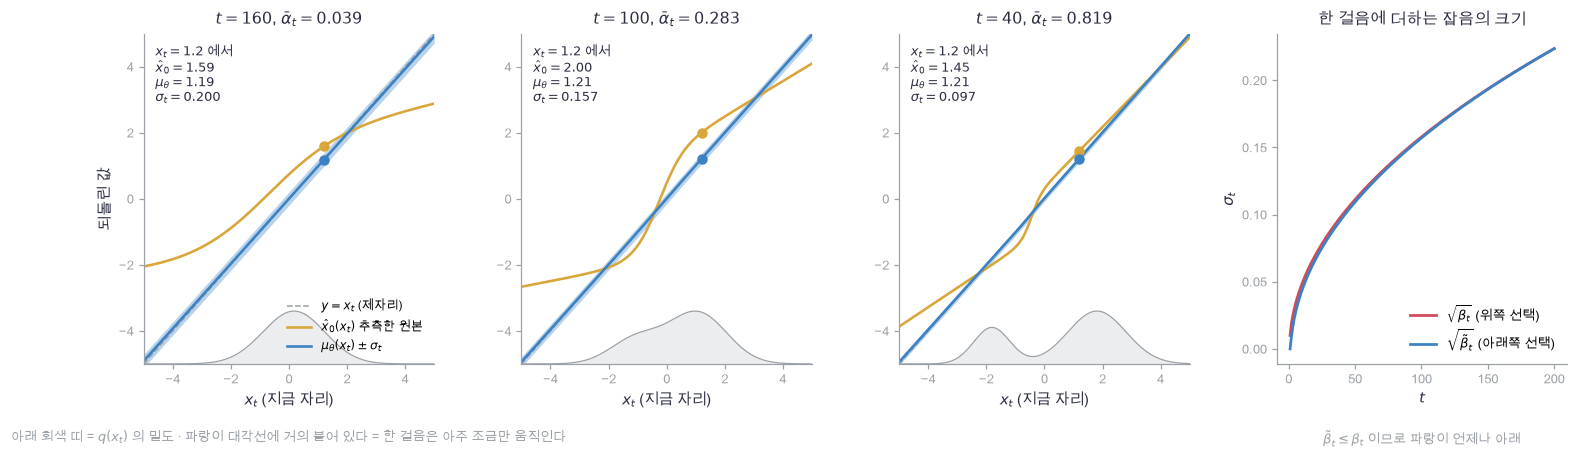

In [14]:
plot_reverse_step(step_panels, step_t_axis, step_sigma_beta, step_sigma_tilde)

🔍 **확인** · 가로축은 지금 자리 $x_t$, 세로축은 되돌린 값입니다. 회색 대각선은 "전혀 움직이지 않음"입니다.
금색 곡선 $\hat x_0(x_t)$는 대각선에서 크게 벗어나 있습니다. $t=160$에서는 잡음이 대부분이라 $\hat x_0$가 두 봉우리 쪽으로 강하게 당겨지고($x_t=1.2$에서 $1.59$), $t=100$에서는 오른쪽 봉우리라고 거의 확신해 $2.00$, $t=40$에서는 원본이 꽤 보여 다시 $x_t$ 쪽인 $1.45$로 옵니다.
파란 곡선 $\mu_\theta(x_t)$는 **대각선에 거의 붙어 있습니다.** 세 시각 모두 한 걸음의 이동이 $0.01$ 남짓입니다($1.2\to1.19,\ 1.21,\ 1.21$). 되묻기 계수 $c_0$가 작아서(34번 2절) "추측한 원본 쪽으로 아주 조금만" 가기 때문입니다. 게다가 파란 띠의 두께 $\sigma_t$($0.10$–$0.20$)가 그 이동보다 열 배쯤 큽니다. **한 걸음만 보면 거의 무작위 흔들림이고, 200걸음이 쌓여야 방향이 드러납니다.**
오른쪽 곡선에서 $\sqrt{\tilde\beta_t}$(파랑)는 언제나 $\sqrt{\beta_t}$(빨강) 아래입니다. $x_0$를 (추측이라도) 알고 되묻는 편이 앞으로 한 걸음 가는 것보다 덜 불확실하다는 34번 2절의 결론이 그대로 쓰입니다. 완성 예제에서 두 선택의 결과를 비교합니다.

아래 구현은 평균 한 줄과, 거기에 잡음을 더하는 한 걸음입니다. 두 함수로 나눈 이유는 평균만 따로 검산하기 위해서입니다.

In [15]:
def ddpm_mean(x_t, t, eps_hat, beta, alpha_bar):
    """역과정 한 걸음의 평균 μ_θ = (x_t − β_t/√(1−ᾱ_t) ε̂)/√α_t. 34번 2절의 되묻기 평균에 x̂₀ 를 넣은 것과 같은 식입니다.
    x_t, eps_hat: (N, D), t: 정수, beta·alpha_bar: (T+1,) → (N, D)."""
    return (x_t - beta[t] / np.sqrt(1 - alpha_bar[t]) * eps_hat) / np.sqrt(1 - beta[t])

In [16]:
def ddpm_step(x_t, t, eps_hat, rng, beta, alpha_bar, variance="beta_tilde"):
    """역과정 한 걸음 x_{t−1} = μ_θ + σ_t z. variance 가 "beta_tilde" 면 σ_t² = β̃_t, "beta" 면 σ_t² = β_t.
    x_t, eps_hat: (N, D), t: 정수, rng: 난수 생성기 → x_{t−1}: (N, D)."""
    # 쓰는 것: ddpm_mean (1절)
    mean = ddpm_mean(x_t, t, eps_hat, beta, alpha_bar)
    if t == 1:
        return mean                                                  # 마지막 걸음: 잡음을 더하면 되돌린 x₀ 를 다시 흐리게 만듭니다
    if variance == "beta":
        variance_t = beta[t]                                         # 위쪽 선택 σ_t² = β_t
    else:
        variance_t = (1 - alpha_bar[t - 1]) / (1 - alpha_bar[t]) * beta[t]   # 아래쪽 선택 σ_t² = β̃_t (34번 2절)
    return mean + np.sqrt(variance_t) * rng.normal(size=np.shape(x_t))

In [17]:
# 쓰는 것: beta, alpha_bar, T (📎 스케줄 셀) · posterior_coefficients (📎 전방 셀) · ddpm_mean (1절)
toy_beta = np.array([0.0, 0.1, 0.2])                                 # 34번 1절의 장난감 스케줄
toy_alpha_bar = np.cumprod(1 - toy_beta)                             # (3,): ᾱ = (1, 0.9, 0.72)
hand_mu = float(ddpm_mean(np.array([[1.1]]), 2, np.array([[0.5]]), toy_beta, toy_alpha_bar)[0, 0])
hand_x0 = (1.1 - np.sqrt(1 - toy_alpha_bar[2]) * 0.5) / np.sqrt(toy_alpha_bar[2])   # x̂₀ (34번 3절)
hand_c0, hand_ct, hand_beta_tilde = posterior_coefficients(2, toy_beta, toy_alpha_bar)
np.testing.assert_allclose(hand_mu, 1.018549, atol=1e-6)             # 검산: 손계산 0.911018/0.894427
np.testing.assert_allclose(hand_x0, 0.984558, atol=1e-6)             # 검산: 손계산 (1.1 − 0.264575)/0.848528
np.testing.assert_allclose(hand_mu, hand_c0 * hand_x0 + hand_ct * 1.1)   # 검산: μ_θ = c₀ x̂₀ + c_t x_t (34번 2절의 되묻기 평균)
np.testing.assert_allclose(np.sqrt(hand_beta_tilde), 0.267261, atol=1e-6)   # 검산: σ₂ = √(1/14)
probe_rng = np.random.default_rng(3502)
probe_x = probe_rng.normal(size=(7, 3))                              # (7, 3): 임의의 x_t
probe_eps = probe_rng.normal(size=(7, 3))                            # (7, 3): 임의의 ε̂
probe_gaps = []                                                      # 시각마다 두 식의 상대오차
for t in range(1, T + 1):
    c0, ct, _ = posterior_coefficients(t, beta, alpha_bar)
    x0_hat = (probe_x - np.sqrt(1 - alpha_bar[t]) * probe_eps) / np.sqrt(alpha_bar[t])
    probe_gaps.append(rel_error(ddpm_mean(probe_x, t, probe_eps, beta, alpha_bar), c0 * x0_hat + ct * probe_x))
assert max(probe_gaps) < 1e-12, "모든 t 에서 μ_θ 가 34번 2절의 posterior 평균과 같아야 합니다"
print(f"손계산 μ_θ = {hand_mu:.6f} = c₀x̂₀ + c_t x_t · σ₂ = {np.sqrt(hand_beta_tilde):.6f} · 200개 시각의 최대 상대오차 {max(probe_gaps):.2e}")

손계산 μ_θ = 1.018549 = c₀x̂₀ + c_t x_t · σ₂ = 0.267261 · 200개 시각의 최대 상대오차 1.81e-13


In [18]:
# 쓰는 것: beta, alpha_bar (📎 스케줄 셀) · posterior_coefficients (📎 전방 셀) · ddpm_mean, ddpm_step (1절)
draw_rng = np.random.default_rng(3503)
draw_x = np.full((60000, 1), 1.2)                                    # (60000, 1): 같은 점에서 한 걸음을 6만 번
draw_eps = np.full((60000, 1), 0.8)                                  # (60000, 1): ε̂ 도 고정
draw_next = ddpm_step(draw_x, 100, draw_eps, draw_rng, beta, alpha_bar)
draw_mu = float(ddpm_mean(draw_x, 100, draw_eps, beta, alpha_bar)[0, 0])
_, _, draw_beta_tilde = posterior_coefficients(100, beta, alpha_bar)
assert abs(float(draw_next.mean()) - draw_mu) < 0.002, "표본 평균이 μ_θ 와 0.002 안에서 같아야 합니다"
assert abs(float(draw_next.var()) / draw_beta_tilde - 1) < 0.02, "표본 분산이 β̃_t 와 2% 안에서 같아야 합니다"
draw_last = ddpm_step(draw_x[:4], 1, draw_eps[:4], draw_rng, beta, alpha_bar)
np.testing.assert_allclose(draw_last, ddpm_mean(draw_x[:4], 1, draw_eps[:4], beta, alpha_bar))   # 검산: 마지막 걸음에는 잡음이 없음
print(f"t = 100: 표본 평균 {float(draw_next.mean()):.5f} vs μ_θ {draw_mu:.5f} · 표본 분산 {float(draw_next.var()):.6f} vs β̃_t {draw_beta_tilde:.6f}")
print("t = 1 에서는 잡음을 더하지 않아 네 표본이 모두 μ_θ 와 같습니다.")

t = 100: 표본 평균 1.19113 vs μ_θ 1.19139 · 표본 분산 0.024783 vs β̃_t 0.024673
t = 1 에서는 잡음을 더하지 않아 네 표본이 모두 μ_θ 와 같습니다.


🔍 **확인** · 손계산 $\mu_\theta=1.018549$가 되묻기 평균 $c_0\hat x_0+c_tx_t$와 정확히 같고, 200개 시각 전부에서 두 식의 상대오차가 $10^{-12}$ 아래입니다. 서로 다르게 생긴 두 수식이 같은 값을 낸다는 것은 위 정리가 맞았다는 뜻입니다.
두 번째 검산은 동어반복이 아닙니다. 같은 점에서 한 걸음을 60,000번 밟아 **실제로 나온 표본의 평균과 분산**을 재니 $\mu_\theta$와 $\tilde\beta_t$에 맞습니다. 그리고 $t=1$에서는 네 표본이 모두 같아 잡음이 더해지지 않은 것을 확인했습니다.

### 🔍 1-1. 정답 $\epsilon$을 알면 정말 되돌아오는가

한 걸음이 맞는 것과 $T$걸음이 원래 분포를 만드는 것은 다른 이야기입니다. 신경망을 학습하기 전에 **$\hat\epsilon$ 자리에 닫힌식 정답 $\epsilon^*$를 끼워 넣고** 200걸음을 밟아 보면, 역과정 자체가 맞는지를 모델의 오차와 분리해 확인할 수 있습니다.
같은 실험을 두 스케줄로 합니다. 이 노트북의 스케줄($\bar\alpha_T=0.006$)과 34번의 스케줄($\bar\alpha_T=0.13$)입니다. 둘 다 $x_T\sim\mathcal N(0,I)$에서 출발합니다.

> **용어**
>
> - **total variation(TV) 거리** $\frac12\sum_b|q_b-p_b|$: 구간 $b$마다의 확률이 두 분포에서 얼마나 다른지. 0이면 같고 1이면 전혀 겹치지 않습니다 (33번 1절). 아래에서 $q_b$는 히스토그램의 구간 확률, $p_b$는 참 밀도에 구간 폭 $0.2$를 곱한 것입니다.

> **코드** · `np.histogram(v, edges)[0]`: 구간 경계 `edges`로 나눈 개수 `(len(edges) − 1,)`. 개수를 (표본 수 × 구간 폭)으로 나누면 밀도와 같은 눈금이 됩니다.

In [19]:
# 쓰는 것: T, beta, alpha_bar, beta_34, alpha_bar_34 (📎 스케줄 셀) · mix_logpdf, mix_responsibility, mix_sample, MIX_PI, MIX_MU (📎 혼합 셀) · optimal_eps (📎 전방 셀) · ddpm_step (1절)
back_x = np.linspace(-6, 6, 1201)                                    # (1201,): 밀도 격자
back_pdf = np.exp(mix_logpdf(back_x))                                # (1201,): 원래 밀도 p(x₀)
back_edges = np.linspace(-6, 6, 61)                                  # (61,): 히스토그램 구간 경계 (폭 0.2)
back_centers = 0.5 * (back_edges[1:] + back_edges[:-1])              # (60,)
back_hists, back_stats = [], []                                      # 스케줄마다 히스토그램과 (TV, 평균, 오른쪽 봉우리 비율)
for schedule_beta, schedule_bar in [(beta, alpha_bar), (beta_34, alpha_bar_34)]:
    back_rng = np.random.default_rng(3511)
    back_sample = back_rng.normal(size=(20000, 1))                   # x_T ~ N(0, I) 에서 출발
    for t in range(T, 0, -1):                                        # T, T−1, …, 1
        back_eps = optimal_eps(back_sample[:, 0], t, schedule_bar)[:, None]   # 신경망 자리에 닫힌식 정답
        back_sample = ddpm_step(back_sample, t, back_eps, back_rng, schedule_beta, schedule_bar)
    counts = np.histogram(back_sample[:, 0], back_edges)[0] / (20000 * 0.2)   # (60,): 밀도 눈금
    back_hists.append(counts)
    # TV 거리 = ½ Σ_b |히스토그램 밀도 − 참 밀도| × 구간 폭 0.2 (밀도 × 폭 = 구간 확률)
    back_stats.append((0.5 * float(np.sum(np.abs(counts - np.exp(mix_logpdf(back_centers))))) * 0.2,
                       float(back_sample.mean()), float(mix_responsibility(back_sample[:, 0]).mean(axis=0)[1])))
back_direct = np.histogram(mix_sample(20000, np.random.default_rng(3510)), back_edges)[0] / (20000 * 0.2)
back_floor = 0.5 * float(np.sum(np.abs(back_direct - np.exp(mix_logpdf(back_centers))))) * 0.2   # 같은 식으로 잰, 표본 잡음만으로 생기는 TV 거리의 바닥
assert back_stats[0][0] < 0.03, "이 노트북 스케줄의 TV 거리는 0.03 아래여야 합니다"
assert back_stats[1][0] > 2 * back_stats[0][0], "34번 스케줄은 출발점이 어긋나 TV 거리가 두 배 이상 커야 합니다"
print("참값: 평균", round(float(np.sum(MIX_PI * MIX_MU)), 3), "· 오른쪽 봉우리 비율", MIX_PI[1])
print("이 노트북 스케줄 (TV, 평균, 비율):", np.round(back_stats[0], 4), "· 34번 스케줄:", np.round(back_stats[1], 4))
print("참 분포에서 바로 뽑은 20,000개의 TV 거리 (표본 잡음의 바닥):", round(back_floor, 4))

참값: 평균 0.8 · 오른쪽 봉우리 비율 0.7
이 노트북 스케줄 (TV, 평균, 비율): [0.0202 0.766  0.6931] · 34번 스케줄: [0.0729 0.4826 0.6442]
참 분포에서 바로 뽑은 20,000개의 TV 거리 (표본 잡음의 바닥): 0.0213


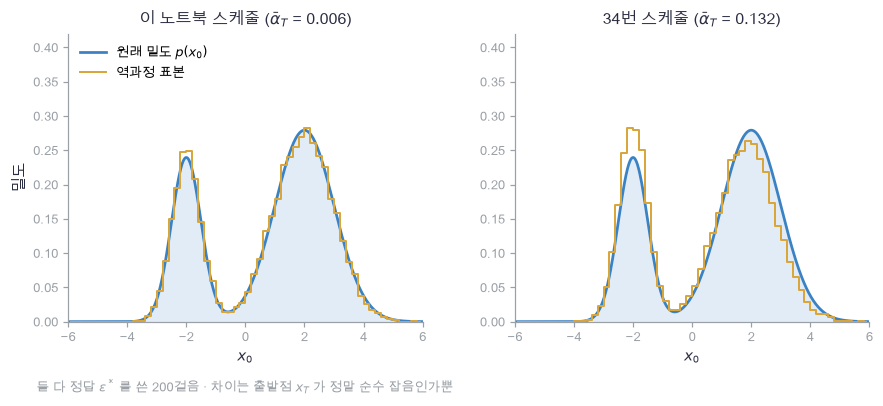

In [20]:
plot_reverse_histograms(back_x, back_pdf, back_centers, back_hists,
                        [f"이 노트북 스케줄 ($\\bar\\alpha_T$ = {alpha_bar[T]:.3f})", f"34번 스케줄 ($\\bar\\alpha_T$ = {alpha_bar_34[T]:.3f})"],
                        "둘 다 정답 $\\epsilon^*$ 를 쓴 200걸음 · 차이는 출발점 $x_T$ 가 정말 순수 잡음인가뿐")

🔍 **확인** · 왼쪽(이 노트북의 스케줄)에서 금색 계단이 파란 밀도와 거의 겹칩니다. TV 거리 $0.020$, 표본 평균 $0.766$(참값 $0.8$), 오른쪽 봉우리 비율 $0.693$(참값 $0.7$)입니다. 참 분포에서 **바로 뽑은** 20,000개로 같은 TV 거리를 재면 $0.021$입니다. 표본 20,000개면 그냥 표본 잡음만으로도 그만큼 어긋난다는 뜻이고, 역과정 표본의 $0.020$은 그 바닥과 구별되지 않습니다. **정답 $\epsilon$만 있으면 잡음 하나가 원래 분포가 됩니다.** 이것이 diffusion 생성의 전부입니다.
오른쪽(34번의 스케줄)은 눈에 띄게 어긋납니다. 왼쪽 봉우리가 너무 크고, 표본 평균이 $0.483$(참값 $0.8$), 비율이 $0.644$입니다. 수식이 틀려서가 아니라 **출발점이 틀려서**입니다. 34번 스케줄에서는 $\bar\alpha_T=0.13$이라 진짜 $q(x_T)$가 아직 두 봉우리의 흔적을 갖고 있는데, 우리는 $\mathcal N(0,I)$에서 출발했습니다. 그 어긋남이 200걸음 동안 그대로 남습니다.
그래서 스케줄을 고르는 첫 기준은 "$\bar\alpha_T$가 0에 충분히 가까운가"입니다. 34번 완성 예제의 코사인 스케줄이 이 문제를 더 세게 해결하는 방법이었습니다.

### ✏️ 연습 1 · 한 걸음의 평균 $\mu_\theta$ 한 줄

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

잡음 낀 점 `x_t` `(N, D)`, 시각 `t`, 모델이 낸 `eps_hat` `(N, D)`에서 $\mu_\theta=\frac{1}{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\hat\epsilon\right)$ 한 줄을 채우세요. 노트북 끝의 연습 A가 같은 값을 $\hat x_0$ 쪽 식으로 묻는다면, 이 연습은 $\hat\epsilon$ 쪽 식입니다. 두 결과가 같아야 합니다.

In [21]:

def exercise_ddpm_mean(x_t, t, eps_hat, beta_values, alpha_bar_values):
    """연습 1: 역과정 한 걸음의 평균 μ_θ. x_t, eps_hat: (N, D), t: 정수 → (N, D)."""
    assert x_t.shape == eps_hat.shape, "x_t 와 ε̂ 는 같은 (N, D) 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: mu = (x_t − β_t/√(1 − ᾱ_t) × eps_hat) / √α_t (모양 (N, D))
    ### 힌트: 1절 ddpm_mean 의 한 줄입니다. β_t 는 beta_values[t], α_t 는 1 − beta_values[t] 입니다.
    raise NotImplementedError
    return mu

In [22]:

def check_ddpm_mean(candidate):
    """1절 손계산(장난감 스케줄 t = 2), 본문 ddpm_mean, 되묻기 평균으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: toy_beta, toy_alpha_bar (1절 검산 셀) · beta, alpha_bar (📎 스케줄 셀) · posterior_coefficients (📎 전방 셀) · ddpm_mean (1절)
    hand_got = candidate(np.array([[1.1]]), 2, np.array([[0.5]]), toy_beta, toy_alpha_bar)
    np.testing.assert_allclose(hand_got, [[1.018549]], atol=1e-6)    # 검산: 손계산 0.911018/0.894427
    x_c = np.random.default_rng(3571).normal(size=(5, 2))
    eps_c = np.random.default_rng(3572).normal(size=(5, 2))
    for t in [1, 30, 120, 200]:
        np.testing.assert_allclose(candidate(x_c, t, eps_c, beta, alpha_bar), ddpm_mean(x_c, t, eps_c, beta, alpha_bar))   # 검산: 본문과 같음
        c0, ct, _ = posterior_coefficients(t, beta, alpha_bar)
        x0_c = (x_c - np.sqrt(1 - alpha_bar[t]) * eps_c) / np.sqrt(alpha_bar[t])
        np.testing.assert_allclose(candidate(x_c, t, eps_c, beta, alpha_bar), c0 * x0_c + ct * x_c)   # 검산: 되묻기 평균과 같음
    print("한 걸음의 평균: 손계산·본문 ddpm_mean·되묻기 평균과 일치합니다.")

run_check(check_ddpm_mean, exercise_ddpm_mean,
          hint="mu = (x_t - beta_values[t] / np.sqrt(1 - alpha_bar_values[t]) * eps_hat) / np.sqrt(1 - beta_values[t])")

☐ exercise_ddpm_mean: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: mu = (x_t - beta_values[t] / np.sqrt(1 - alpha_bar_values[t]) * eps_hat) / np.sqrt(1 - beta_values[t])


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
mu = (x_t - beta_values[t] / np.sqrt(1 - alpha_bar_values[t]) * eps_hat) / np.sqrt(1 - beta_values[t])
```

</details>

## 🔑 2. $T$걸음 루프, 그리고 $\hat\epsilon$ 자리에 신경망 끼우기

**이 절에서 가져갈 것:** 샘플링은 `x = rng.normal(...)`로 시작해 $t=T,T-1,\dots,1$로 `ddpm_step`을 반복하는 **for 문 하나**입니다. $\hat\epsilon$ 자리에는 무엇이든 넣을 수 있습니다. 닫힌식 정답을 넣으면 역과정이 맞는지 확인하는 도구가 되고, 34번 4절의 신경망을 넣으면 실제 생성 모델이 됩니다.

1절의 한 걸음은 $x_t$를 받아 $x_{t-1}$을 냅니다. 그러면 $x_T$에서 시작해 200번 부르면 $x_0$가 나옵니다. 정말 그게 전부입니다.
어려운 부분은 이미 34번에서 끝났습니다. 남은 일은 그 신경망을 다시 학습해 루프에 끼우는 것뿐입니다. 먼저 정답 $\epsilon^*$로 "점들이 어떻게 움직이는지"를 보고, 그다음에 신경망으로 바꿉니다.

> **용어**
>
> - **샘플링 루프(sampling loop)**: $t$를 큰 값에서 작은 값으로 내려가며 한 걸음 함수를 반복하는 for 문. 33번 4절의 annealed Langevin과 모양이 같지만, 걸음마다 **시각이 하나씩 줄어드는 점**이 다릅니다.
> - **$\epsilon$ 함수(eps_fn)**: 샘플러에 넘기는 함수 `eps_fn(x, t)`. 무엇이 $\hat\epsilon$을 내는지만 정해 주면 샘플러는 신경 쓰지 않습니다. 이 노트북에서는 닫힌식·학습한 모델·guidance 결합을 모두 이 자리에 끼웁니다.

$x$는 $(N,D)$이고 루프가 도는 동안 모양이 바뀌지 않습니다. 걸음마다 바뀌는 것은 값과 시각뿐입니다.

$$x_T\sim\mathcal N(0,I),\qquad x_{t-1}=\texttt{ddpm\_step}(x_t,\ t,\ \texttt{eps\_fn}(x_t,t)),\quad t=T,\dots,1 .$$

아래는 1차원 혼합에서 점 60개가 200걸음 동안 지나간 길입니다. $\hat\epsilon$ 자리에는 닫힌식 $\epsilon^*$를 넣었습니다.

In [23]:
# 쓰는 것: T, beta, alpha_bar (📎 스케줄 셀) · mix_responsibility (📎 혼합 셀) · optimal_eps (📎 전방 셀) · ddpm_step (1절)
path_rng = np.random.default_rng(3512)
path_x = path_rng.normal(size=(60, 1))                               # (60, 1): 출발점 x_T 60 개
path_history = [path_x[:, 0].copy()]                                 # 시각마다 60 개의 위치
for t in range(T, 0, -1):
    path_eps = optimal_eps(path_x[:, 0], t, alpha_bar)[:, None]      # 닫힌식 정답을 ε̂ 자리에
    path_x = ddpm_step(path_x, t, path_eps, path_rng, beta, alpha_bar)
    path_history.append(path_x[:, 0].copy())
path_history = np.array(path_history)                                # (201, 60): 행 = 시각, 열 = 점
path_t_axis = np.arange(T, -1, -1)                                   # (201,): T 에서 0 까지
path_right = mix_responsibility(path_x[:, 0])[:, 1] > 0.5            # (60,) bool: 오른쪽 봉우리에 도착했는가
print("출발 x_T 의 평균·표준편차:", round(float(path_history[0].mean()), 3), round(float(path_history[0].std()), 3))
print("도착 x_0 의 평균·표준편차:", round(float(path_x.mean()), 3), round(float(path_x.std()), 3),
      "· 오른쪽 봉우리에 도착한 점", int(path_right.sum()), "/ 60")

출발 x_T 의 평균·표준편차: 0.039 1.008
도착 x_0 의 평균·표준편차: 0.605 1.945 · 오른쪽 봉우리에 도착한 점 39 / 60


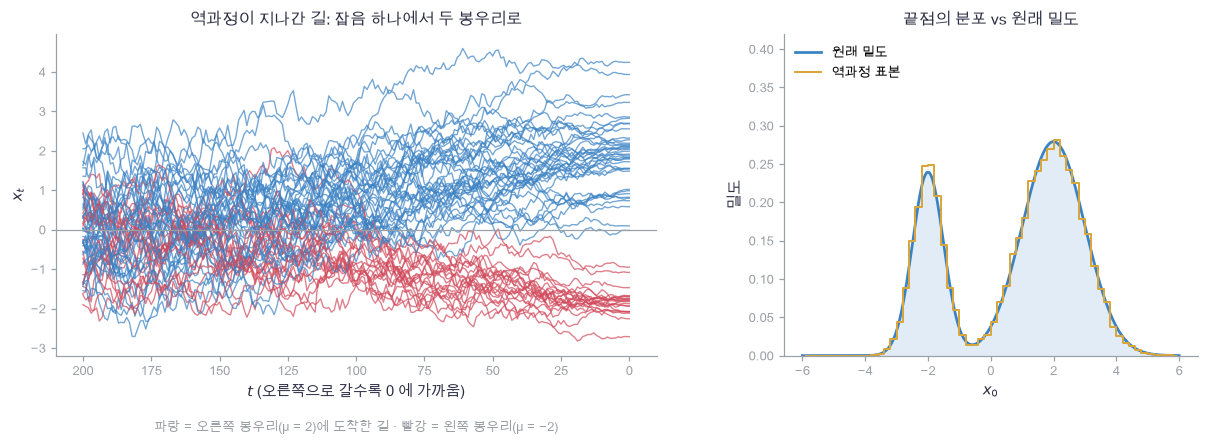

In [24]:
plot_reverse_paths(path_t_axis, path_history, back_x, back_pdf, back_centers, back_hists[0], path_right)

🔍 **확인** · 왼쪽 그림의 맨 왼쪽($t=T$)에서 60개 점은 모두 0 근처에 몰려 있습니다. 순수 잡음이니 당연합니다. 오른쪽으로 갈수록 선들이 **두 갈래로 갈라져** $-2$와 $2$ 근처로 모입니다. 갈라지는 시점은 대략 $t\approx100$ 언저리이고, 그 뒤로는 자기 봉우리 안에서만 흔들립니다.
왜 갈라질까요? 큰 $t$에서는 $\hat x_0$가 거의 0(두 봉우리의 평균)이라 어느 쪽으로도 끌리지 않습니다. $t$가 작아지면서 $x_t$의 부호가 조금만 기울어도 $\hat x_0$가 한쪽 봉우리로 확 쏠리고, 그 뒤로는 그쪽으로만 당겨집니다. **어느 봉우리가 될지는 걸음마다 더한 잡음이 정합니다.**
오른쪽은 1-1절의 20,000개 표본 히스토그램입니다. 60개 선의 결말을 20,000개로 늘려 보면 원래 밀도가 그대로 나옵니다.

아래 구현은 그 for 문을 함수로 묶은 것입니다. `record`에 시각을 주면 도중의 $x_t$도 남겨 줍니다(MNIST에서 "그림이 나타나는 과정"을 볼 때 씁니다).

In [25]:
def ddpm_sample(eps_fn, shape, beta, alpha_bar, rng, variance="beta_tilde", record=()):
    """x_T ~ N(0, I) 에서 t = T…1 로 ddpm_step 을 반복합니다. eps_fn(x, t) 가 (N, D) 잡음 예측을 내면 됩니다.
    shape: (N, D), record: 도중에 남길 시각들 → (x_0: (N, D), trace: {t: (N, D)})."""
    # 쓰는 것: ddpm_step (1절)
    x = rng.normal(size=shape)                                       # x_T: 순수 잡음에서 출발
    trace = {}
    for t in range(len(alpha_bar) - 1, 0, -1):                       # T, T−1, …, 1
        if t in record:
            trace[t] = x.copy()
        x = ddpm_step(x, t, eps_fn(x, t), rng, beta, alpha_bar, variance)
    trace[0] = x.copy()
    return x, trace

In [26]:
def mix_eps_fn(x, t):
    """1차원 혼합의 닫힌식 정답을 ε̂ 자리에 넣는 ε 함수. 신경망이 아무리 잘 배워도 이 값에 다가갈 뿐입니다 (34번 3절).
    x: (N, 1), t: 정수 → (N, 1)."""
    # 쓰는 것: optimal_eps (📎 전방 셀) · alpha_bar (📎 스케줄 셀)
    return optimal_eps(x[:, 0], t, alpha_bar)[:, None]

In [27]:
# 쓰는 것: T, beta, alpha_bar (📎 스케줄 셀) · MIX_PI, MIX_MU, MIX_SIGMA, mix_responsibility (📎 혼합 셀) · back_edges, back_hists (1-1절 계산 셀) · ddpm_sample, mix_eps_fn (2절)
loop_sample, _ = ddpm_sample(mix_eps_fn, (20000, 1), beta, alpha_bar, np.random.default_rng(3511))
loop_counts = np.histogram(loop_sample[:, 0], back_edges)[0] / (20000 * 0.2)
np.testing.assert_allclose(loop_counts, back_hists[0])               # 검산: 1-1절의 손으로 쓴 반복문과 완전히 같은 표본
loop_ratio = mix_responsibility(loop_sample[:, 0]).mean(axis=0)      # (2,): 성분별 평균 책임확률 = 봉우리 비율
loop_true_std = float(np.sqrt(np.sum(MIX_PI * (MIX_SIGMA ** 2 + MIX_MU ** 2)) - np.sum(MIX_PI * MIX_MU) ** 2))
assert np.max(np.abs(loop_ratio - MIX_PI)) < 0.02, "봉우리 비율이 π 와 0.02 안에서 같아야 합니다"
assert abs(float(loop_sample.mean()) - np.sum(MIX_PI * MIX_MU)) < 0.06, "표본 평균이 Σ π_k μ_k 와 0.06 안에서 같아야 합니다"
assert abs(float(loop_sample.std()) - loop_true_std) < 0.06, "표본 표준편차가 닫힌식과 0.06 안에서 같아야 합니다"
print("봉우리 비율", np.round(loop_ratio, 4), "vs π", MIX_PI, "· 평균", round(float(loop_sample.mean()), 4),
      "vs", round(float(np.sum(MIX_PI * MIX_MU)), 4), "· 표준편차", round(float(loop_sample.std()), 4), "vs", round(loop_true_std, 4))

봉우리 비율 [0.3069 0.6931] vs π [0.3 0.7] · 평균 0.766 vs 0.8 · 표준편차 2.0294 vs 2.0335


🔍 **확인** · `ddpm_sample`이 1-1절에서 손으로 쓴 반복문과 **완전히 같은 표본**을 냅니다(같은 seed, 같은 난수 사용 순서). 함수로 묶는 과정에서 아무것도 바뀌지 않았다는 확인입니다.
그리고 20,000개 표본의 봉우리 비율·평균·표준편차가 혼합의 닫힌식 값과 맞습니다. 이 셋은 히스토그램과 달리 **숫자로** 비교할 수 있어, 뒤에서 sampler를 바꿀 때마다 같은 잣대로 재겠습니다.

이제 $\hat\epsilon$ 자리를 신경망으로 바꿉니다. 아래 다섯 셀은 34번 4절의 잡음 예측 모델을 그대로 다시 쓴 것입니다. 입력은 $(x_t,t)$, 출력은 $\hat\epsilon$, 손실은 $\frac1N\sum_n\|\hat\epsilon_n-\epsilon_n\|^2$입니다. `init_denoiser`의 `labels` 칸만 4절을 위해 미리 열어 두었습니다(지금은 0).

> **코드**
>
> - `table[:, 0::2], table[:, 1::2] = np.sin(angles), np.cos(angles)`: 짝수 열에 sin, 홀수 열에 cos을 한 번에 (09번 4절).
> - `np.concatenate([x_t, emb], axis=1)`: 좌표 축(열)으로 이어 붙여 `(N, D)` + `(N, E)` → `(N, D + E)`.
> - `rng.integers(1, T + 1, size=batch)`: 1부터 T까지의 정수를 batch개 뽑습니다(복원추출). 스텝마다 시각을 새로 고릅니다.

In [28]:
def time_embedding(t, E):
    """34번 4절: 09번 4절의 sinusoidal 표를 시각에 적용. emb(t)[2i] = sin(t/10000^(2i/E)), emb(t)[2i+1] = cos(·).
    t: (N,) 정수 또는 숫자 하나, E: 짝수 폭 → (N, E)."""
    assert E % 2 == 0, "sin·cos 쌍을 두려면 폭 E 가 짝수여야 합니다"
    times = np.asarray(t, dtype=float).reshape(-1, 1)                # (N, 1)
    even = np.arange(0, E, 2)[None, :]                               # (1, E/2): 짝수 좌표 번호
    angles = times / (10000 ** (even / E))                           # (N, E/2)
    table = np.empty((len(times), E))
    table[:, 0::2], table[:, 1::2] = np.sin(angles), np.cos(angles)
    return table

In [29]:
def init_denoiser(D, E, hidden, seed, labels=0):
    """34번 4절의 파라미터: W1 (D+E+labels, hidden), b1, W2 (hidden, D), b2. 03번 4절에서 본 초기화(여기서는 표준편차 1/√입력을 씁니다).
    labels 는 label one-hot 칸 수입니다(4절에서 11 로 씁니다). 지금은 0."""
    rng_init = np.random.default_rng(seed)
    n_in = D + E + labels
    return {"W1": rng_init.normal(size=(n_in, hidden)) / np.sqrt(n_in), "b1": np.zeros(hidden),
            "W2": rng_init.normal(size=(hidden, D)) / np.sqrt(hidden), "b2": np.zeros(D)}


def denoiser_forward(x_t, t, p):
    """34번 4절: U = [x_t, emb(t)], A = tanh(U W1 + b1), ε̂ = A W2 + b2.
    x_t: (N, D), t: (N,) 정수 → (eps_hat: (N, D), cache: (U, A))."""
    # 쓰는 것: time_embedding (2절)
    E = p["W1"].shape[0] - x_t.shape[1]                              # 시간 표의 폭 = 입력 폭 − 데이터 차원
    U = np.concatenate([x_t, time_embedding(t, E)], axis=1)          # (N, D+E): 좌표 축으로 이어 붙임
    A = np.tanh(U @ p["W1"] + p["b1"])                               # (N, hidden)
    return A @ p["W2"] + p["b2"], (U, A)

In [30]:
def denoiser_backward(d_eps, cache, p):
    """34번 4절(=03번 5절): dW2 = Aᵀ dε̂, db2 = Σ dε̂, dA = dε̂ W2ᵀ, dZ = dA ⊙ (1 − A²), dW1 = Uᵀ dZ, db1 = Σ dZ.
    d_eps: (N, D), cache: forward 의 것 → grads: p 와 같은 키의 사전."""
    U, A = cache
    dA = d_eps @ p["W2"].T                                           # (N, hidden)
    dZ = dA * (1 - A ** 2)                                           # tanh 의 도함수 1 − A²
    return {"W1": U.T @ dZ, "b1": dZ.sum(axis=0), "W2": A.T @ d_eps, "b2": d_eps.sum(axis=0)}


def mse_loss(eps_hat, eps):
    """34번 4절의 단순화 손실 J = mean_n ‖ε̂_n − ε_n‖² 와 출력 기울기 ∂J/∂ε̂ = 2(ε̂ − ε)/N.
    eps_hat, eps: (N, D) → (J: 숫자, d_eps: (N, D))."""
    residual = eps_hat - eps                                         # (N, D): 예측 − 정답
    return float(np.mean(np.sum(residual ** 2, axis=1))), 2 * residual / len(eps_hat)

In [31]:
def adam_step(p, grads, state, step, lr):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p 를 제자리에서 바꾸고 state 의 (m, v)를 갱신합니다."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                               # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                      # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [32]:
def train_denoiser(X0, alpha_bar, steps, seed, hidden=64, embed=16, batch=256, lr=3e-3):
    """34번 4절의 학습 루프: 미니배치 x₀ 를 뽑고, 시각 t 를 1…T 에서 고르게 뽑고, 새 ε 으로 x_t 를 만들어 ε 을 맞히게 합니다.
    X0: (N, D) 깨끗한 데이터 → (p: 파라미터 사전, history: 스텝별 손실 (steps,))."""
    # 쓰는 것: init_denoiser, denoiser_forward, denoiser_backward, mse_loss, adam_step (2절) · q_sample (📎 전방 셀)
    last = len(alpha_bar) - 1                                        # T (스케줄 배열의 마지막 번호)
    p = init_denoiser(X0.shape[1], embed, hidden, seed)
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}   # Adam 상태 (m, v)
    rng_train = np.random.default_rng(seed + 1)
    history = []
    for step in range(1, steps + 1):
        X_batch = X0[rng_train.choice(len(X0), batch, replace=False)]   # (batch, D)
        t = rng_train.integers(1, last + 1, size=batch)                 # (batch,): 스텝마다 고르게 뽑은 시각
        eps = rng_train.normal(size=X_batch.shape)                      # (batch, D): 새 잡음
        eps_hat, cache = denoiser_forward(q_sample(X_batch, t, eps, alpha_bar), t, p)
        loss, d_eps = mse_loss(eps_hat, eps)
        adam_step(p, denoiser_backward(d_eps, cache, p), state, step, lr)
        history.append(loss)
    return p, np.array(history)

In [33]:
# 쓰는 것: init_denoiser, denoiser_forward, denoiser_backward, mse_loss (2절)
grad_p = init_denoiser(2, 8, 8, 3513)                                # 작은 2차원 모델 (은닉 8, 시간 표 8)
grad_rng = np.random.default_rng(3514)
grad_xt = grad_rng.normal(size=(5, 2))                               # (5, 2): 검사용 x_t
grad_eps = grad_rng.normal(size=(5, 2))                              # (5, 2): 검사용 정답 ε
grad_t = np.array([3, 50, 120, 200, 1])                              # (5,): 표본마다 다른 시각
grad_hat, grad_cache = denoiser_forward(grad_xt, grad_t, grad_p)
grad_grads = denoiser_backward(mse_loss(grad_hat, grad_eps)[1], grad_cache, grad_p)


def grad_scalar():
    """검사기용: 현재 파라미터의 MSE 손실 (같은 입력·시각·정답)."""
    return mse_loss(denoiser_forward(grad_xt, grad_t, grad_p)[0], grad_eps)[0]


grad_errors = {key: rel_error(grad_grads[key], numerical_gradient(grad_scalar, value)) for key, value in grad_p.items()}
assert max(grad_errors.values()) < 1e-6, "네 파라미터의 기울기가 중심차분과 1e−6 안에서 같아야 합니다"
print("잡음 예측 모델 gradcheck 최대 상대오차:", max(grad_errors.values()))

잡음 예측 모델 gradcheck 최대 상대오차: 4.157649292818271e-10


🔍 **확인** · 34번에서 유도한 backward가 여기서도 중심차분과 $10^{-6}$ 안에서 맞습니다. 학습을 돌리기 전에 이것부터 확인합니다(학습이 잘 된다는 것만으로 미분이 맞다고 판단하지 않습니다).

이제 2차원 혼합에서 학습하고, 같은 루프에 **닫힌식 정답**과 **학습한 모델**을 각각 끼워 비교합니다. 학습용 작은 문제의 성능이며 실제 벤치마크로 읽지 마세요.

In [34]:
# 쓰는 것: alpha_bar, beta (📎 스케줄 셀) · mix2_sample, mix2_logpdf, mix2_responsibility, MIX2_PI, MIX2_MU, MIX2_COV (📎 혼합 셀) · optimal_eps2 (📎 전방 셀) · train_denoiser, denoiser_forward, ddpm_sample (2절)
two_X0 = mix2_sample(4000, np.random.default_rng(347))               # (4000, 2): 2차원 학습 데이터
two_p, two_history = train_denoiser(two_X0, alpha_bar, 3000, 348)
two_mean = (MIX2_PI[:, None] * MIX2_MU).sum(axis=0)                  # (2,): 닫힌식 평균 Σ π_k μ_k
two_cov = sum(MIX2_PI[k] * (MIX2_COV[k] + np.outer(MIX2_MU[k], MIX2_MU[k])) for k in range(2)) - np.outer(two_mean, two_mean)
print(f"2차원 MSE 손실 {two_history[:100].mean():.4f} → {two_history[-200:].mean():.4f} (바닥이 0 이 아님)")
print("닫힌식 평균", np.round(two_mean, 3), "· 닫힌식 공분산의 첫 행", np.round(two_cov[0], 3))

2차원 MSE 손실 1.1438 → 0.8398 (바닥이 0 이 아님)
닫힌식 평균 [0.4 0.6] · 닫힌식 공분산의 첫 행 [4.32 0.98]


In [35]:
# 쓰는 것: alpha_bar, beta (📎 스케줄 셀) · optimal_eps2, mix2_responsibility (📎 셀) · denoiser_forward, ddpm_sample (2절) · two_p, two_mean, two_cov (2절 학습 셀)
def two_star_eps(X, t):
    """2차원 혼합의 닫힌식 정답 ε*. X: (N, 2), t: 정수 → (N, 2)."""
    # 쓰는 것: optimal_eps2 (📎 전방 셀) · alpha_bar (📎 스케줄 셀)
    return optimal_eps2(X, t, alpha_bar)


def two_model_eps(X, t):
    """방금 학습한 2차원 모델의 ε̂. X: (N, 2), t: 정수 → (N, 2)."""
    # 쓰는 것: denoiser_forward (2절) · two_p (2절 학습 셀)
    return denoiser_forward(X, np.full(len(X), t), two_p)[0]

In [36]:
# 쓰는 것: beta, alpha_bar (📎 스케줄 셀) · MIX2_PI, mix2_responsibility, mix2_logpdf (📎 혼합 셀) · ddpm_sample (2절) · two_X0, two_mean, two_cov, two_star_eps, two_model_eps (2절)
two_star_Z, _ = ddpm_sample(two_star_eps, (4000, 2), beta, alpha_bar, np.random.default_rng(3521))
two_model_Z, _ = ddpm_sample(two_model_eps, (4000, 2), beta, alpha_bar, np.random.default_rng(3521))
two_stats = []                                                       # (봉우리 비율, 평균 오차, 공분산 오차)
for Z in [two_star_Z, two_model_Z]:
    two_stats.append((float(mix2_responsibility(Z).mean(axis=0)[1]), float(np.max(np.abs(Z.mean(axis=0) - two_mean))),
                      float(np.max(np.abs(np.cov(Z.T) - two_cov)))))
assert abs(two_stats[0][0] - MIX2_PI[1]) < 0.02, "닫힌식 ε* 의 봉우리 비율은 π 와 0.02 안에서 같아야 합니다"
assert two_stats[0][1] < 0.06, "닫힌식 ε* 의 평균 오차는 0.06 아래여야 합니다"
assert two_stats[0][2] < 0.12, "닫힌식 ε* 의 공분산 오차는 0.12 아래여야 합니다"
assert abs(two_stats[1][0] - MIX2_PI[1]) < 0.08, "학습한 모델의 봉우리 비율도 π 근처여야 합니다"
assert two_stats[1][1] < 0.5, "학습한 모델의 평균 오차는 0.5 아래여야 합니다"
two_xx, two_yy = np.meshgrid(np.linspace(-5, 5, 161), np.linspace(-3.5, 4, 121))
two_pdf = np.exp(mix2_logpdf(np.column_stack([two_xx.ravel(), two_yy.ravel()]))).reshape(two_xx.shape)
print("(오른쪽 봉우리 비율, 평균 최대오차, 공분산 최대오차)")
print("  닫힌식 ε*:", np.round(two_stats[0], 4), "· 학습한 ε̂:", np.round(two_stats[1], 4), "· 참 비율", MIX2_PI[1])

(오른쪽 봉우리 비율, 평균 최대오차, 공분산 최대오차)
  닫힌식 ε*: [0.5944 0.0349 0.0643] · 학습한 ε̂: [0.6477 0.1818 0.5525] · 참 비율 0.6


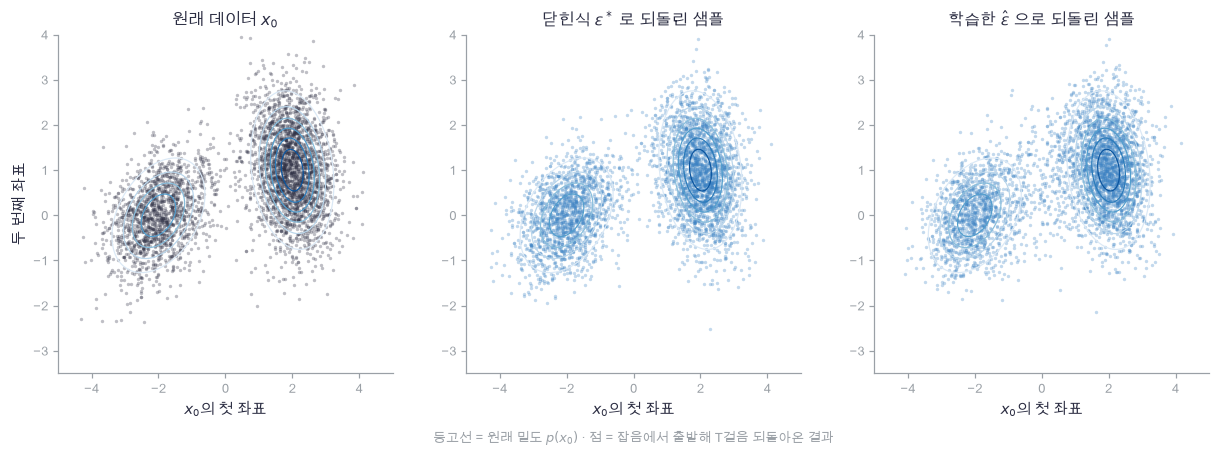

In [37]:
plot_samples_2d(two_xx, two_yy, two_pdf,
                [("원래 데이터 $x_0$", two_X0), ("닫힌식 $\\epsilon^*$ 로 되돌린 샘플", two_star_Z),
                 ("학습한 $\\hat\\epsilon$ 으로 되돌린 샘플", two_model_Z)])

🔍 **확인** · 세 산점이 같은 등고선 위에 있습니다. 가운데(닫힌식 정답)는 원래 데이터와 구별하기 어렵고, 봉우리 비율도 $0.4/0.6$과 $0.02$ 안에서 같습니다.
오른쪽(학습한 모델)은 모양은 맞지만 봉우리 비율이 조금 치우치고 오른쪽 덩어리가 살짝 퍼져 있습니다. 은닉 64짜리 MLP 하나를 3,000스텝 학습한 것이라 작은 $t$에서의 $\hat\epsilon$ 오차가 남고, 그 오차가 200걸음 동안 쌓입니다. **역과정은 맞지만 모델이 근사이기 때문에 생기는 차이**입니다. 가운데 패널이 그 둘을 갈라 줍니다.

같은 코드를 MNIST PCA-32 좌표에 씁니다. 데이터 차원이 32로 커질 뿐 바뀌는 줄이 없습니다.

In [38]:
# 쓰는 것: mnist_Z, mnist_norm (📎 PCA 셀) · beta, alpha_bar (📎 스케줄 셀) · train_denoiser, denoiser_forward, ddpm_sample (2절)
gen_p, gen_history = train_denoiser(mnist_Z, alpha_bar, 3000, 349, hidden=256, lr=2e-3)


def gen_eps(Z, t):
    """MNIST 좌표에서 학습한 모델의 ε̂. Z: (N, 32), t: 정수 → (N, 32)."""
    # 쓰는 것: denoiser_forward (2절) · gen_p (2절 MNIST 학습 셀)
    return denoiser_forward(Z, np.full(len(Z), t), gen_p)[0]


print(f"MNIST 좌표 32 개의 제곱합 손실 {gen_history[:100].mean():.3f} → {gen_history[-300:].mean():.3f}")

MNIST 좌표 32 개의 제곱합 손실 16.881 → 10.103


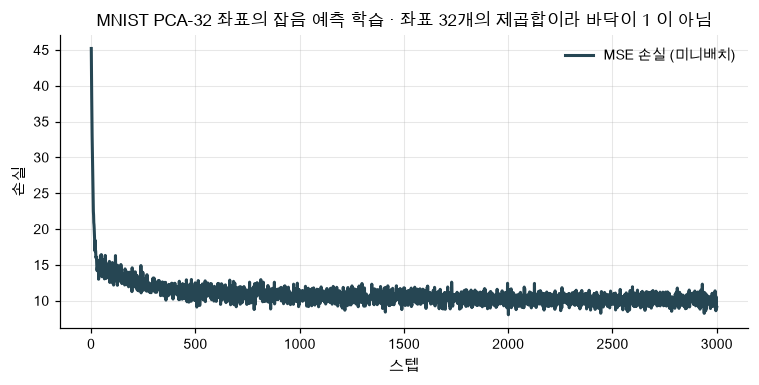

In [39]:
plot_curves(np.arange(1, len(gen_history) + 1), {"MSE 손실 (미니배치)": gen_history},
            title="MNIST PCA-32 좌표의 잡음 예측 학습 · 좌표 32개의 제곱합이라 바닥이 1 이 아님", ylabel="손실")

In [40]:
# 쓰는 것: mnist_Z, mnist_norm (📎 PCA 셀) · decode_pca, nearest_class (📎 PCA 셀) · beta, alpha_bar (📎 스케줄 셀) · ddpm_sample, gen_eps (2절)
gen_shot_ts = [200, 150, 100, 50, 20, 0]                             # 스냅숏을 남길 시각
gen_Z, gen_trace = ddpm_sample(gen_eps, (16, 32), beta, alpha_bar, np.random.default_rng(3520), record=tuple(gen_shot_ts))
gen_images = decode_pca(gen_Z)                                       # (16, 28, 28)
gen_digits = nearest_class(gen_Z)                                    # (16,): 가장 가까운 클래스 평균
gen_counts = np.bincount(gen_digits, minlength=10)                   # (10,): 숫자별 개수
gen_rows = [[decode_pca(gen_trace[t][row:row + 1])[0] for t in gen_shot_ts] for row in range(3)]   # 표본 3개의 과정
gen_norm = float(np.linalg.norm(gen_Z, axis=1).mean())
assert 0.7 * mnist_norm < gen_norm < 1.3 * mnist_norm, "샘플 좌표의 길이가 데이터와 같은 규모여야 합니다"
assert np.count_nonzero(gen_counts) >= 4, "만든 16장에 서로 다른 숫자가 4가지 이상 있어야 합니다"
print("샘플 좌표의 평균 길이", round(gen_norm, 3), "· 데이터", round(mnist_norm, 3))
print("숫자별 개수", gen_counts, "· 서로 다른 숫자", int(np.count_nonzero(gen_counts)), "가지")

샘플 좌표의 평균 길이 5.059 · 데이터 5.589
숫자별 개수 [0 3 6 0 1 0 0 2 0 4] · 서로 다른 숫자 5 가지


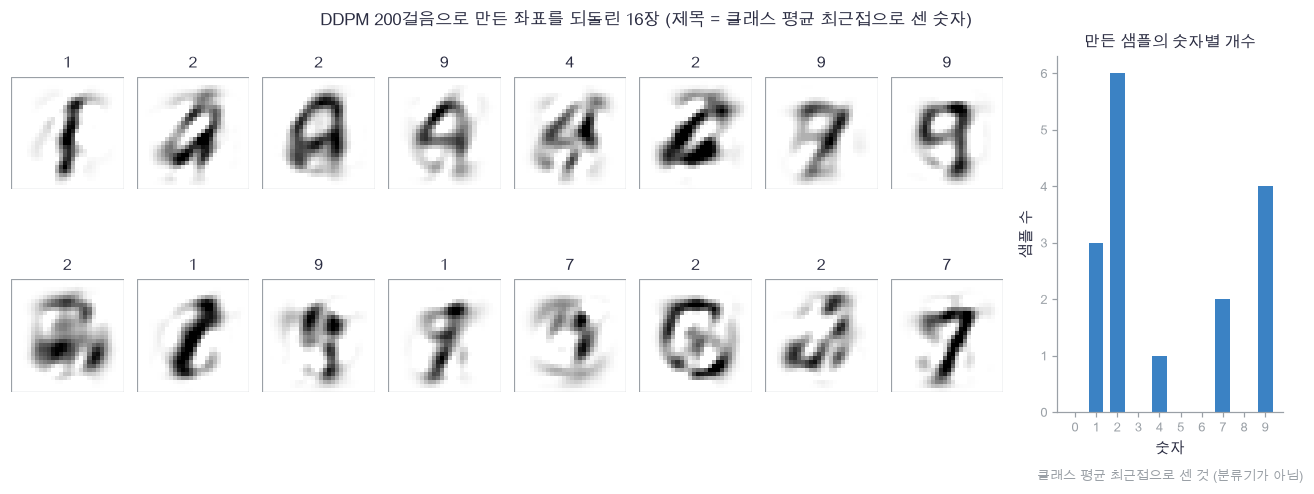

In [41]:
plot_sample_grid(gen_images, gen_digits, gen_counts,
                 "DDPM 200걸음으로 만든 좌표를 되돌린 16장 (제목 = 클래스 평균 최근접으로 센 숫자)")

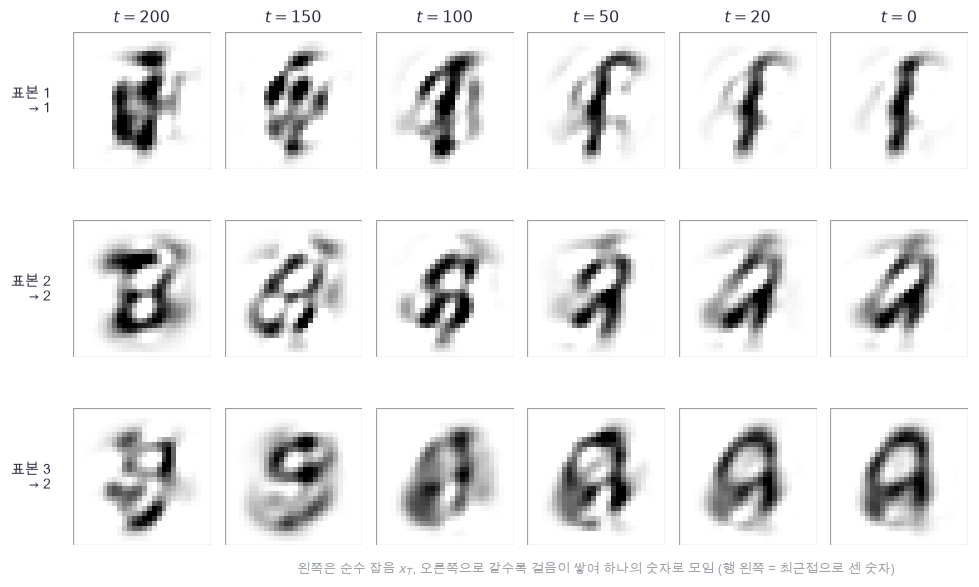

In [42]:
plot_snapshot_strip(gen_rows, gen_shot_ts, [str(d) for d in gen_digits[:3]])

🔍 **확인** · 16장 가운데 대부분이 숫자처럼 보이고, 몇 장은 획이 뭉개져 읽기 어렵습니다. 숫자별 개수 막대를 보면 몇 숫자(1·2·9)에 몰려 있습니다. 주성분 32개가 원래 분산의 4분의 3만 담고, 모델은 은닉 256짜리 MLP 하나이며 학습은 3,000스텝입니다. **학습용 작은 문제의 결과**이며 실제 생성 모델의 품질로 읽지 마세요.
아래 띠가 이 노트북에서 가장 볼만한 그림입니다. 맨 왼쪽 $t=200$은 순수 잡음 좌표 $x_T\sim\mathcal N(0,I)$를 되돌린 것이라 획처럼 보이는 얼룩만 있고 어떤 숫자인지 알 수 없습니다. 화소마다 따로 튀는 잡음이 아닌 것은 `decode_pca`가 매끄러운 고유이미지 32장을 섞어 평균 이미지에 더하기 때문입니다. **좌표 공간의 순수 잡음은 화소 공간에서 이렇게 뭉개진 얼룩으로 보입니다.** $t=100$에서 큰 덩어리가 잡히고, $t=50$부터 획이 정리되며, $t=0$에서 하나의 숫자가 됩니다. 34번 4절에서 "한 번에 되돌리면 흐릿하다"고 했던 그 문제를, **걸음마다 잡음을 조금씩 다시 섞어** 하나의 선명한 답으로 좁혀 가는 것입니다.
그림 하나를 만드는 데 $\hat\epsilon$을 200번 불렀습니다. 다음 절에서 이 비용을 줄입니다.

### ✏️ 연습 2 · 마지막 걸음에는 잡음을 더하지 않습니다

평균 `mean` `(N, D)`, 시각 `t`, 걸음의 잡음 크기 `sigma`, 표준정규 `z` `(N, D)`에서 한 걸음의 마지막 줄을 채우세요. $t=1$이면 `mean` 그대로, 아니면 `mean + sigma * z`입니다. 이 한 줄을 빠뜨리면 애써 되돌린 $x_0$에 잡음을 한 번 더 뿌리게 됩니다.

In [43]:

def exercise_add_noise(mean, t, sigma, z):
    """연습 2: 한 걸음의 마지막 줄. t = 1 이면 평균 그대로, 아니면 mean + σ z. mean, z: (N, D) → (N, D)."""
    assert mean.shape == z.shape, "평균과 잡음은 같은 (N, D) 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x_prev = t 가 1 이면 mean, 아니면 mean + sigma * z (모양 (N, D))
    ### 힌트: 1절 ddpm_step 의 마지막 두 줄입니다. if t == 1: 로 갈라 씁니다.
    raise NotImplementedError
    return x_prev

In [44]:

def check_add_noise(candidate):
    """손계산 두 경우와 본문 ddpm_step 이 실제로 내는 값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: beta, alpha_bar (📎 스케줄 셀) · posterior_coefficients (📎 전방 셀) · ddpm_mean, ddpm_step (1절)
    hand_mean = np.array([[1.0, -2.0]])
    hand_z = np.array([[0.5, 2.0]])
    np.testing.assert_allclose(candidate(hand_mean, 1, 0.3, hand_z), hand_mean)          # 검산: t = 1 이면 잡음 없음
    np.testing.assert_allclose(candidate(hand_mean, 2, 0.3, hand_z), [[1.15, -1.4]])     # 검산: 손계산 1 + 0.3×0.5, −2 + 0.3×2
    x_c = np.random.default_rng(3573).normal(size=(4, 2))
    eps_c = np.random.default_rng(3574).normal(size=(4, 2))
    mean_c = ddpm_mean(x_c, 50, eps_c, beta, alpha_bar)
    _, _, beta_tilde_c = posterior_coefficients(50, beta, alpha_bar)
    z_c = np.random.default_rng(3575).normal(size=(4, 2))                                 # ddpm_step 이 쓸 잡음과 같은 것
    got = candidate(mean_c, 50, np.sqrt(beta_tilde_c), z_c)
    np.testing.assert_allclose(got, ddpm_step(x_c, 50, eps_c, np.random.default_rng(3575), beta, alpha_bar))   # 검산: 본문 ddpm_step 과 같음
    print("마지막 걸음의 조건: 손계산·본문 ddpm_step 과 일치합니다.")

run_check(check_add_noise, exercise_add_noise, hint="if t == 1: x_prev = mean · else: x_prev = mean + sigma * z")

☐ exercise_add_noise: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: if t == 1: x_prev = mean · else: x_prev = mean + sigma * z


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
if t == 1:
    x_prev = mean
else:
    x_prev = mean + sigma * z
```

</details>

## 🔑 3. DDIM: 잡음을 빼면 걸음을 건너뛸 수 있습니다

**이 절에서 가져갈 것:** 한 걸음을 $x_{t-1}=\sqrt{\bar\alpha_{t-1}}\,\hat x_0+\sqrt{1-\bar\alpha_{t-1}-\sigma^2}\,\hat\epsilon+\sigma z$로 쓰면, $\sigma$를 0으로 두는 순간 걸음이 **결정적**이 되어 같은 $x_T$가 언제나 같은 $x_0$를 줍니다. 게다가 이 식에는 "$t$와 $t-1$이 이웃이어야 한다"는 조건이 없어서, $200\to178\to156\to\cdots$처럼 **건너뛴 시간열**로도 걸을 수 있습니다. $\eta=1$이고 전체 시간열이면 DDPM과 정확히 같아집니다.

2절의 그림 하나에 $\hat\epsilon$을 200번 불렀습니다. 실제 모델에서는 이 호출 하나가 큰 신경망 한 번이라 200번이 곧 비용입니다. 걸음을 줄일 수 없을까요?
DDPM의 걸음은 줄이기 어렵습니다. 걸음마다 잡음을 더하는 **확률 과정**이라 중간을 건너뛰면 분포가 달라집니다. 그런데 잡음을 빼면 이야기가 달라집니다.

> **용어**
>
> - **DDIM (denoising diffusion implicit models)**: 같은 학습된 $\hat\epsilon$을 쓰면서 걸음에서 잡음을 빼거나 줄이는 sampler. 학습을 다시 하지 않습니다.
> - $\eta$ (**잡음 비율**): 걸음에 남길 잡음의 비율. $\eta=0$이면 결정적, $\eta=1$이면 DDPM($\sigma_t^2=\tilde\beta_t$)과 같습니다.
> - **부분 시간열(sub-sequence)**: $T$부터 1까지 전부가 아니라 고르게 $S$개만 고른 시각 목록. 걸음 수 $S$가 곧 $\hat\epsilon$ 호출 수입니다.

시각 $t$에서 그보다 앞선 시각 $s<t$로 한 번에 갑니다. $x_t$·$\hat\epsilon$·$\hat x_0$는 $(N,D)$, $\bar\alpha_t$·$\bar\alpha_s$·$\sigma$는 숫자 하나입니다.

$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\hat\epsilon}{\sqrt{\bar\alpha_t}},\qquad
x_s=\sqrt{\bar\alpha_s}\,\hat x_0+\sqrt{1-\bar\alpha_s-\sigma^2}\;\hat\epsilon+\sigma z,\qquad
\sigma=\eta\sqrt{\frac{1-\bar\alpha_s}{1-\bar\alpha_t}\left(1-\frac{\bar\alpha_t}{\bar\alpha_s}\right)}.$$

두 번째 식을 말로 읽으면 "추측한 원본을 시각 $s$의 크기 $\sqrt{\bar\alpha_s}$로 줄이고, 그 시각에 있어야 할 잡음의 양만큼 $\hat\epsilon$을 다시 섞는다"입니다. 34번 1절의 닫힌식 $x_s=\sqrt{\bar\alpha_s}x_0+\sqrt{1-\bar\alpha_s}\epsilon$과 같은 모양이고, 모르는 $x_0$와 $\epsilon$ 자리에 추측을 넣은 것입니다.

$\eta=1$이고 $s=t-1$이면 $\sigma^2=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t=\tilde\beta_t$이고($\bar\alpha_t/\bar\alpha_{t-1}=\alpha_t$이므로), 나머지 두 계수도 34번 2절의 $c_0,c_t$와 정확히 같아집니다. 즉 **DDPM은 DDIM의 한 경우**입니다. 아래 검산에서 계수를 직접 맞춰 봅니다.

$s=0$일 때는 $\bar\alpha_0=1$이라 $\sigma=0$이고 $x_0=\hat x_0$입니다. 마지막 걸음이 저절로 "잡음 없이 $\hat x_0$를 내놓기"가 됩니다.

아래는 2차원 혼합에서 **같은 출발점 여섯 개**를 걸음 수만 바꿔 $\eta=0$으로 걸어 본 것입니다. 식을 그대로 NumPy로 씁니다.

In [45]:
# 쓰는 것: T, alpha_bar (📎 스케줄 셀) · optimal_eps2 (📎 전방 셀)
ddim_start = np.random.default_rng(3530).normal(size=(6, 2))         # (6, 2): 네 설정이 모두 쓰는 같은 출발점 x_T
ddim_counts = [10, 20, 50, 200]                                      # 걸음 수 S
ddim_paths, ddim_times = {}, {}                                      # S → 경로 (S+1, 6, 2) 와 시간열
for S in ddim_counts:
    times = np.unique(np.linspace(T, 1, S).round().astype(int))[::-1]   # (S,): 내림차순 부분 시간열
    point = ddim_start.copy()
    path = [point]
    for i, t in enumerate(times):
        s = times[i + 1] if i + 1 < len(times) else 0                # 다음 시각 (마지막은 0)
        eps_hat = optimal_eps2(point, t, alpha_bar)                  # 닫힌식 정답을 ε̂ 자리에
        x0_hat = (point - np.sqrt(1 - alpha_bar[t]) * eps_hat) / np.sqrt(alpha_bar[t])
        point = np.sqrt(alpha_bar[s]) * x0_hat + np.sqrt(1 - alpha_bar[s]) * eps_hat   # η = 0 이라 잡음 항이 없음
        path.append(point)
    ddim_paths[S] = np.array(path)
    ddim_times[S] = times
ddim_gap = float(np.max(np.abs(ddim_paths[10][-1] - ddim_paths[200][-1])))   # 10걸음과 200걸음의 도착점 차이
print("S = 10 의 시간열 앞부분:", ddim_times[10][:4], "…", ddim_times[10][-1])
print("S = 10 의 도착점\n", np.round(ddim_paths[10][-1], 3), "\nS = 200 의 도착점\n", np.round(ddim_paths[200][-1], 3))
print("두 도착점의 최대 차이:", round(ddim_gap, 4))

S = 10 의 시간열 앞부분: [200 178 156 134] … 1
S = 10 의 도착점
 [[-1.511 -0.096]
 [ 2.306  0.443]
 [ 2.346  1.736]
 [-2.289 -0.433]
 [ 1.329  1.489]
 [-1.791 -0.81 ]] 
S = 200 의 도착점
 [[-1.65  -0.201]
 [ 2.422  0.372]
 [ 2.465  1.865]
 [-2.453 -0.553]
 [ 1.349  1.597]
 [-1.917 -1.026]]
두 도착점의 최대 차이: 0.2163


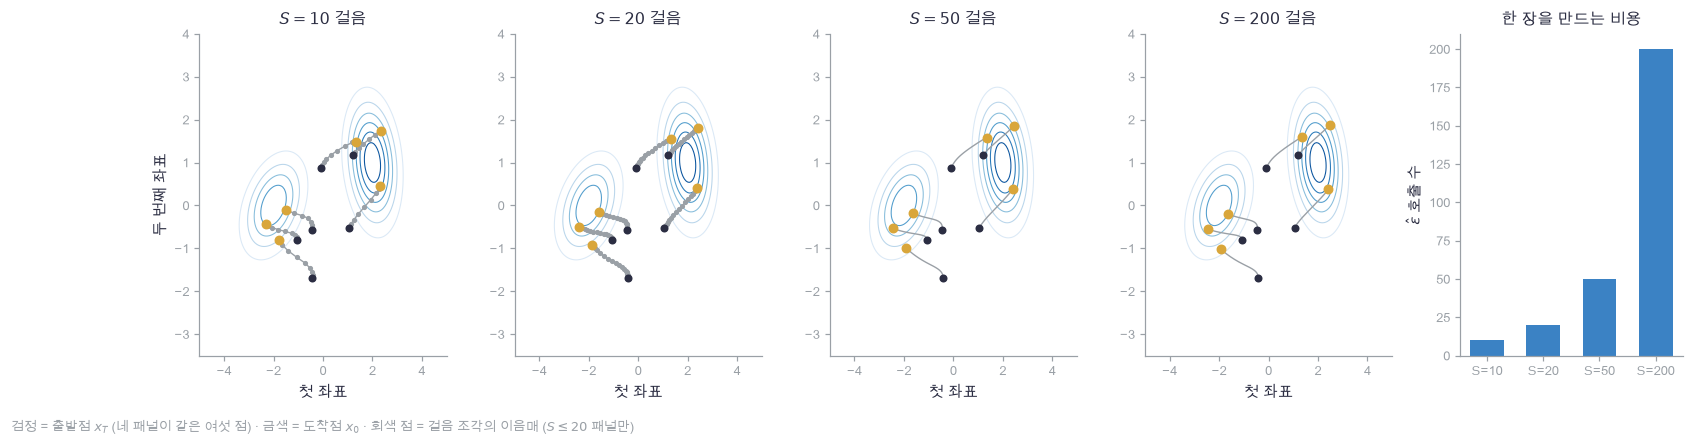

In [46]:
plot_ddim_paths(two_xx, two_yy, two_pdf, ddim_paths, ddim_counts, ddim_counts)

🔍 **확인** · 네 패널이 같은 검은 출발점 여섯 개에서 시작합니다. 금색 도착점이 네 패널에서 거의 같은 자리입니다(최대 차이 $0.22$, 봉우리 사이 거리 $4$에 비하면 작습니다). **걸음 수를 20분의 1로 줄여도 같은 곳에 도착합니다.**
경로의 모양도 눈으로는 거의 같습니다. $S=10$ 경로는 직선 조각 열 개를 이은 것이지만, 조각 하나가 길어야 좌표 $0.37$(패널 폭 $10$의 4% 남짓)이라 $S=200$의 촘촘한 곡선과 구별되지 않습니다. 왼쪽 두 패널에만 조각의 이음매를 점으로 찍었으니 세어 보세요. 같은 곡선을 굵게 샘플링한 것입니다. DDPM의 경로가 지그재그로 흔들리던 것(2절 왼쪽 그림)과 달리 여기는 흔들림이 없습니다. 잡음을 빼서 결정적이기 때문입니다.
$S$를 줄이면 조각이 굵어져 곡선에서 조금씩 벗어납니다. 그 차이가 $S=10$에서의 $0.22$입니다.

아래 구현은 부분 시간열 만들기, 한 걸음, 전체 루프입니다.

> **코드** · `np.unique(a)[::-1]`: 중복을 없애고 오름차순으로 정렬한 뒤 뒤집어 내림차순으로 만듭니다. `np.linspace(T, 1, S).round().astype(int)`가 이미 내림차순이지만, $S$가 커져 같은 정수가 두 번 나오는 경우를 없앱니다.

In [47]:
def uniform_times(last, steps):
    """T…1 에서 고르게 고른 내림차순 부분 시간열. steps 개의 시각을 고르고 중복을 없앱니다.
    last: T, steps: 걸음 수 S ≥ 2 → 내림차순 정수 배열 (첫 원소 T, 마지막 원소 1, 중복을 없애므로 길이는 S 이하)."""
    assert 2 <= steps <= last, "걸음 수는 2 이상 T 이하여야 합니다"
    return np.unique(np.linspace(last, 1, steps).round().astype(int))[::-1]

In [48]:
def ddim_step(x_t, t, s, eps_hat, alpha_bar, rng=None, eta=0.0):
    """DDIM 한 걸음 x_s = √ᾱ_s x̂₀ + √(1 − ᾱ_s − σ²) ε̂ + σ z. eta = 0 이면 결정적이고 rng 가 필요 없습니다.
    x_t, eps_hat: (N, D), t > s ≥ 0 정수 → x_s: (N, D)."""
    assert t > s >= 0, "DDIM 은 시각 t 에서 그보다 앞선 s 로 갑니다"
    ab_t, ab_s = alpha_bar[t], alpha_bar[s]
    x0_hat = (x_t - np.sqrt(1 - ab_t) * eps_hat) / np.sqrt(ab_t)     # 34번 3절의 한 줄
    sigma = eta * np.sqrt((1 - ab_s) / (1 - ab_t) * (1 - ab_t / ab_s))   # η = 1 이면 √β̃_t (s = t−1 일 때)
    x_s = np.sqrt(ab_s) * x0_hat + np.sqrt(max(1 - ab_s - sigma ** 2, 0.0)) * eps_hat
    if sigma > 0:
        x_s = x_s + sigma * rng.normal(size=np.shape(x_t))
    return x_s

In [49]:
def ddim_sample(eps_fn, shape, alpha_bar, rng, steps=50, eta=0.0):
    """부분 시간열을 따라 ddim_step 을 반복합니다. ε̂ 호출 수 = steps 이고, 마지막 걸음은 s = 0 이라 x₀ = x̂₀ 입니다.
    eps_fn(x, t) → (N, D), shape: (N, D) → x_0: (N, D)."""
    # 쓰는 것: uniform_times, ddim_step (3절)
    times = uniform_times(len(alpha_bar) - 1, steps)                 # (S,): 내림차순 시각
    x = rng.normal(size=shape)                                       # x_T: 순수 잡음에서 출발
    for i, t in enumerate(times):
        s = times[i + 1] if i + 1 < len(times) else 0                # 다음 시각 (마지막은 0)
        x = ddim_step(x, t, s, eps_fn(x, t), alpha_bar, rng, eta)
    return x

In [50]:
# 쓰는 것: T, beta, alpha_bar (📎 스케줄 셀) · posterior_coefficients (📎 전방 셀) · ddim_paths, ddim_times, ddim_start (3절 계산 셀) · optimal_eps2 (📎 전방 셀) · uniform_times, ddim_step (3절)
np.testing.assert_allclose(uniform_times(T, T), np.arange(T, 0, -1))   # 검산: S = T 면 전체 시간열 T…1
assert uniform_times(T, 10)[0] == T, "부분 시간열은 T 에서 시작해야 합니다"
assert uniform_times(T, 10)[-1] == 1, "부분 시간열은 1 에서 끝나야 합니다"
assert np.all(np.diff(uniform_times(T, 10)) < 0), "부분 시간열은 내림차순이어야 합니다"
coef_gaps = []                                                       # η = 1, s = t−1 에서 DDPM 계수와의 상대오차
for t in [2, 60, 137, 200]:
    ab_t, ab_s = alpha_bar[t], alpha_bar[t - 1]
    sigma_squared = (1 - ab_s) / (1 - ab_t) * (1 - ab_t / ab_s)      # η = 1 의 σ²
    c0, ct, beta_tilde = posterior_coefficients(t, beta, alpha_bar)
    coef_gaps.append([abs(sigma_squared / beta_tilde - 1),           # σ² = β̃_t
                      abs(np.sqrt(ab_s) / (c0 + ct * np.sqrt(ab_t)) - 1),                 # x̂₀ 의 계수
                      abs(np.sqrt(1 - ab_s - sigma_squared) / (ct * np.sqrt(1 - ab_t)) - 1)])   # ε̂ 의 계수
assert np.max(coef_gaps) < 1e-9, "η = 1 · s = t−1 이면 DDIM 의 세 계수가 DDPM 과 같아야 합니다"
first_s = int(ddim_times[10][1])                                     # S = 10 의 두 번째 시각
first_step = ddim_step(ddim_start, T, first_s, optimal_eps2(ddim_start, T, alpha_bar), alpha_bar)
np.testing.assert_allclose(first_step, ddim_paths[10][1])            # 검산: 위 그림 경로의 첫 걸음과 같음
print(f"DDPM 계수와의 최대 상대오차 {np.max(coef_gaps):.2e} · 부분 시간열 S = 10: {uniform_times(T, 10)}")

DDPM 계수와의 최대 상대오차 2.59e-13 · 부분 시간열 S = 10: [200 178 156 134 112  89  67  45  23   1]


In [51]:
# 쓰는 것: T, beta, alpha_bar (📎 스케줄 셀) · ddpm_sample, mix_eps_fn (2절) · ddim_sample (3절)
same_ddim = ddim_sample(mix_eps_fn, (500, 1), alpha_bar, np.random.default_rng(3531), steps=T, eta=1.0)
same_ddpm, _ = ddpm_sample(mix_eps_fn, (500, 1), beta, alpha_bar, np.random.default_rng(3531))
np.testing.assert_allclose(same_ddim, same_ddpm, atol=1e-12)         # 검산: η = 1 · S = T 는 DDPM 과 표본까지 같음
repeat_a = ddim_sample(mix_eps_fn, (50, 1), alpha_bar, np.random.default_rng(3532), steps=20)
repeat_b = ddim_sample(mix_eps_fn, (50, 1), alpha_bar, np.random.default_rng(3532), steps=20)
np.testing.assert_allclose(repeat_a, repeat_b, atol=0.0)             # 검산: η = 0 이면 같은 x_T 가 언제나 같은 x₀
repeat_noisy = ddim_sample(mix_eps_fn, (50, 1), alpha_bar, np.random.default_rng(3532), steps=20, eta=1.0)
assert np.max(np.abs(repeat_a - repeat_noisy)) > 0.5, "η = 1 이면 같은 x_T 라도 결과가 달라져야 합니다"
print(f"η = 1 · S = T 와 DDPM 의 최대 차이 {np.max(np.abs(same_ddim - same_ddpm)):.2e}")
print(f"η = 0 두 번 실행의 차이 {np.max(np.abs(repeat_a - repeat_b)):.1e} · η = 1 로 바꾸면 {np.max(np.abs(repeat_a - repeat_noisy)):.2f}")

η = 1 · S = T 와 DDPM 의 최대 차이 8.86e-14
η = 0 두 번 실행의 차이 0.0e+00 · η = 1 로 바꾸면 5.25


🔍 **확인** · 세 가지가 확인됐습니다. (1) $\eta=1$이고 전체 시간열이면 DDIM의 세 계수가 DDPM의 $c_0,c_t,\tilde\beta_t$와 상대오차 $10^{-9}$ 안에서 같고, **같은 난수를 쓰면 표본까지 $10^{-12}$ 안에서 같습니다.** 두 sampler는 같은 식의 두 경우입니다.
(2) $\eta=0$으로 두면 두 번 실행한 결과가 비트 단위로 같습니다. 난수를 쓰는 곳은 출발점 $x_T$ 하나뿐이기 때문입니다. $\eta=1$로 바꾸면 곧바로 달라집니다.
(3) 3절 그림의 첫 걸음이 `ddim_step` 한 번과 같습니다.

이제 2절에서 학습한 MNIST 모델을 그대로 쓰면서 sampler만 바꿔 봅니다. 학습은 다시 하지 않습니다.

In [52]:
# 쓰는 것: T, alpha_bar (📎 스케줄 셀) · decode_pca, nearest_class, mnist_norm (📎 PCA 셀) · gen_eps (2절) · uniform_times, ddim_step (3절)
shot_start = np.random.default_rng(3533).normal(size=(8, 32))        # (8, 32): 네 줄이 모두 쓰는 같은 x_T
shot_rows, shot_labels, shot_norms = [], [], []
for S in [200, 50, 20, 10]:
    times = uniform_times(T, S)
    point = shot_start.copy()
    for i, t in enumerate(times):
        s = int(times[i + 1]) if i + 1 < len(times) else 0
        point = ddim_step(point, int(t), s, gen_eps(point, int(t)), alpha_bar)
    shot_rows.append(decode_pca(point))
    shot_labels.append(f"$S = {S}$")
    shot_norms.append(float(np.linalg.norm(point, axis=1).mean()))
shot_digits = nearest_class(point)                                   # (8,): 마지막 줄(S = 10)이 고른 숫자
assert max(shot_norms) < 1.6 * mnist_norm, "DDIM 샘플의 좌표 길이도 데이터와 같은 규모여야 합니다 (여덟 장이라 흔들립니다)"
print("걸음 수별 샘플 좌표의 평균 길이:", np.round(shot_norms, 3), "· 데이터", round(mnist_norm, 3))

걸음 수별 샘플 좌표의 평균 길이: [7.185 7.131 7.025 6.84 ] · 데이터 5.589


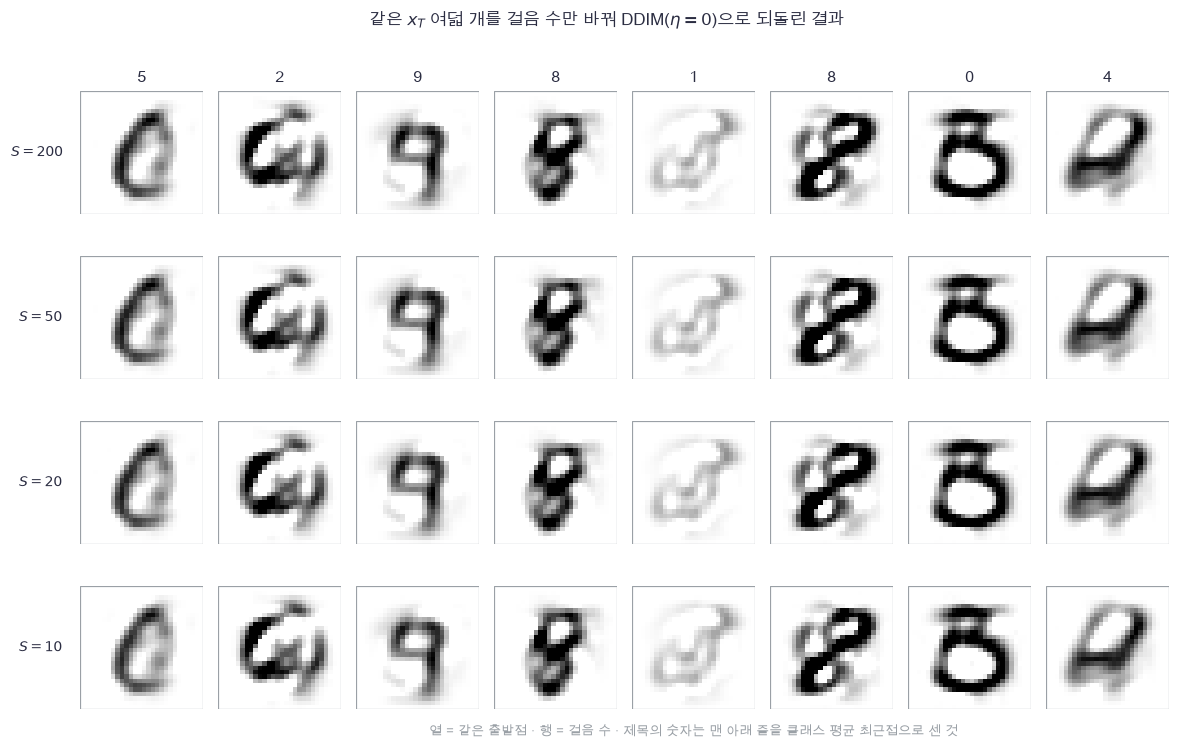

In [53]:
plot_image_rows(shot_rows, shot_labels, [str(d) for d in shot_digits], "같은 $x_T$ 여덟 개를 걸음 수만 바꿔 DDIM($\\eta = 0$)으로 되돌린 결과",
                caption="열 = 같은 출발점 · 행 = 걸음 수 · 제목의 숫자는 맨 아래 줄을 클래스 평균 최근접으로 센 것")

🔍 **확인** · 네 줄이 거의 같은 그림입니다. 200걸음과 10걸음의 결과를 나란히 두어도 어느 쪽이 어느 쪽인지 말하기 어렵습니다. 자세히 보면 걸음이 적을수록 획이 조금 더 뭉툭합니다.
**비용은 20배 차이**입니다($\hat\epsilon$ 호출 200번 vs 10번). 큰 모델에서는 이것이 곧 몇 분과 몇 초의 차이입니다. 대신 잃은 것이 있습니다. $\eta=0$이면 출발점 하나가 결과 하나를 결정하므로, 같은 $x_T$에서 여러 그림을 얻을 수 없습니다. 다양성은 $x_T$를 다시 뽑아서만 얻습니다.
5절에서 걸음 수를 줄였을 때 "조건이 얼마나 지켜지는가"까지 숫자로 비교합니다.

### ✏️ 연습 3 · DDIM 한 걸음 ($\eta = 0$)

시각 `t`에서 `s`로 가는 결정적 걸음 $x_s=\sqrt{\bar\alpha_s}\,\hat x_0+\sqrt{1-\bar\alpha_s}\,\hat\epsilon$ 한 줄을 채우세요. $\hat x_0$는 34번 3절의 한 줄로 이미 구해 두었습니다. $s=0$이면 $\bar\alpha_0=1$이라 $x_0=\hat x_0$가 저절로 나오는지도 확인합니다.

In [54]:

def exercise_ddim_step(x_t, t, s, eps_hat, alpha_bar_values):
    """연습 3: η = 0 인 DDIM 한 걸음. x_t, eps_hat: (N, D), t > s ≥ 0 → x_s: (N, D)."""
    assert t > s >= 0, "DDIM 은 시각 t 에서 그보다 앞선 s 로 갑니다"
    ab_t, ab_s = alpha_bar_values[t], alpha_bar_values[s]             # ᾱ_t 와 ᾱ_s
    x0_hat = (x_t - np.sqrt(1 - ab_t) * eps_hat) / np.sqrt(ab_t)      # 34번 3절의 한 줄
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x_s = √ab_s × x0_hat + √(1 − ab_s) × eps_hat (모양 (N, D))
    ### 힌트: 34번 1절의 닫힌식 x_s = √ᾱ_s x₀ + √(1 − ᾱ_s) ε 에서 모르는 두 값을 추측으로 바꾼 것입니다.
    raise NotImplementedError
    return x_s

In [55]:

def check_ddim_step(candidate):
    """손계산 두 경우와 본문 ddim_step(η = 0), 3절 그림의 경로로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: T, alpha_bar (📎 스케줄 셀) · optimal_eps2 (📎 전방 셀) · ddim_step (3절) · ddim_start, ddim_times, ddim_paths (3절 계산 셀)
    hand_bar = np.array([1.0, 0.64, 0.36])                           # 걸음 두 개짜리 장난감 스케줄의 ᾱ
    np.testing.assert_allclose(candidate(np.array([[1.0]]), 2, 0, np.array([[0.5]]), hand_bar), [[1.0]], atol=1e-9)    # 검산: x̂₀ = (1 − 0.8×0.5)/0.6 = 1, s = 0 이면 그대로
    np.testing.assert_allclose(candidate(np.array([[1.0]]), 2, 1, np.array([[0.5]]), hand_bar), [[1.1]], atol=1e-9)    # 검산: 0.8×1 + 0.6×0.5 = 1.1
    x_c = np.random.default_rng(3576).normal(size=(5, 2))
    eps_c = np.random.default_rng(3577).normal(size=(5, 2))
    for t, s in [(200, 178), (60, 30), (7, 0)]:
        np.testing.assert_allclose(candidate(x_c, t, s, eps_c, alpha_bar), ddim_step(x_c, t, s, eps_c, alpha_bar))   # 검산: 본문과 같음
    first_s = int(ddim_times[10][1])
    path_got = candidate(ddim_start, T, first_s, optimal_eps2(ddim_start, T, alpha_bar), alpha_bar)
    np.testing.assert_allclose(path_got, ddim_paths[10][1])          # 검산: 3절 그림 경로의 첫 걸음
    print("DDIM 한 걸음: 손계산·본문 ddim_step·3절 경로와 일치합니다.")

run_check(check_ddim_step, exercise_ddim_step, hint="x_s = np.sqrt(ab_s) * x0_hat + np.sqrt(1 - ab_s) * eps_hat")

☐ exercise_ddim_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x_s = np.sqrt(ab_s) * x0_hat + np.sqrt(1 - ab_s) * eps_hat


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x_s = np.sqrt(ab_s) * x0_hat + np.sqrt(1 - ab_s) * eps_hat
```

</details>

## 🔑 4. 원하는 숫자를 지정하기: label 조건과 classifier-free guidance

**이 절에서 가져갈 것:** 모델 입력에 label $y$를 이어 붙여 학습하되 **확률 $p_{\text{uncond}}$로 $y$를 비워** 두면, 하나의 모델이 조건부 $\hat\epsilon(x_t,t,y)$와 무조건 $\hat\epsilon(x_t,t,\varnothing)$를 모두 배웁니다. 샘플링할 때 둘을 $\tilde\epsilon=(1+w)\hat\epsilon(x_t,t,y)-w\,\hat\epsilon(x_t,t,\varnothing)$로 섞으면 조건을 더 세게 밀어붙일 수 있습니다. $w=0$이면 조건부 그대로이고, $w$가 클수록 지정한 숫자에 가까워지는 대신 표본이 한쪽으로 몰립니다.

지금까지 만든 그림은 "무엇이든 하나"였습니다. 2절의 16장에서 3이 몇 장 나올지 우리가 정할 수 없었습니다. 그런데 학습 데이터에는 정답 숫자 $y$가 붙어 있습니다. 그것을 모델에 함께 보여 주면 됩니다.
$t$를 알려 주려고 시간 표를 이어 붙였듯이(34번 4절), $y$도 이어 붙이면 그만입니다. 새 backward도, 새 손실도 없습니다.

> **용어**
>
> - **조건부 생성(conditional generation)**: 원하는 속성 $y$(여기서는 숫자 0–9)를 지정해 샘플을 만드는 것. 모델이 $\hat\epsilon(x_t,t,y)$를 내면 역과정의 모든 걸음이 그 조건 아래에서 진행됩니다.
> - **빈 label $\varnothing$**: "조건 없음"을 뜻하는 특별한 label. 여기서는 번호 10을 씁니다. 학습 중 확률 $p_{\text{uncond}}$로 진짜 label을 이것으로 바꿔 놓습니다.
> - **classifier-free guidance** $w$: 조건부와 무조건 예측의 차이를 $w$배 더 밀어 주는 방법. 따로 분류기를 학습하지 않아 "classifier-free"입니다.
> - **one-hot**: 번호 $k$를 "$k$번째만 1이고 나머지는 0"인 벡터로 적는 것 (00b번 4절). one-hot을 입력에 이어 붙이면 $W_1$의 그 행이 곧 그 label의 embedding입니다.

입력이 한 덩이 늘어날 뿐입니다. label 칸 수를 $L=11$(숫자 10개 + 빈 label)이라 하면

$$U=[\,x_t\;\;\mathrm{emb}(t)\;\;\mathrm{onehot}(y)\,]\in\mathbb R^{N\times(D+E+L)},\qquad
A=\tanh(UW_1+b_1),\quad \hat\epsilon=AW_2+b_2 .$$

$W_1$만 $(D+E+L,H)$로 커지고 나머지는 그대로입니다. 학습 배치를 만들 때 각 표본을 확률 $p_{\text{uncond}}$로 골라 $y\leftarrow\varnothing$으로 바꿉니다. 그래서 같은 파라미터가 두 가지 예측을 함께 배웁니다.

샘플링할 때의 결합은 한 줄입니다. $\hat\epsilon$ 둘과 $\tilde\epsilon$ 모두 $(N,D)$이고 $w$는 숫자 하나입니다.

$$\boxed{\;\tilde\epsilon=(1+w)\,\hat\epsilon(x_t,t,y)-w\,\hat\epsilon(x_t,t,\varnothing)\;}$$

왜 이 모양일까요? 34번 3절에서 $\hat\epsilon$은 score와 $\nabla\log q=-\hat\epsilon/\sqrt{1-\bar\alpha_t}$로 이어집니다. 위 결합을 score로 옮기면 $(1+w)\nabla\log q(x_t\mid y)-w\nabla\log q(x_t)=\nabla\log\frac{q(x_t\mid y)^{1+w}}{q(x_t)^{w}}$입니다. 즉 "조건이 있을 때가 없을 때보다 그럴듯한 쪽"을 $w$배 더 따라가라는 뜻입니다.

**손계산** 어떤 자리에서 $\hat\epsilon(\cdot,y)=0.5$, $\hat\epsilon(\cdot,\varnothing)=0.2$라면
$w=0$: $1\times0.5-0\times0.2=0.5$, $w=1$: $2\times0.5-1\times0.2=0.8$, $w=3$: $4\times0.5-3\times0.2=1.4$입니다. 차이 $0.3$이 $w$배만큼 더 얹힙니다.

아래에서는 신경망 없이 결합이 무엇을 하는지 봅니다. 1차원 혼합의 **성분 번호를 label로** 보면 조건부 $\epsilon$도 닫힌식으로 쓸 수 있기 때문입니다. $y=0$은 왼쪽 봉우리 $\mathcal N(-2,0.5^2)$입니다.

In [56]:
def mix_eps_given(x, t, k, alpha_bar):
    """성분 k 를 label 로 알 때의 닫힌식 최적 ε. 성분 하나는 Gaussian 이라 E[x₀|x_t, k] = μ_k + σ_k²/(σ_k²+σ_t²)(x_t/√ᾱ_t − μ_k).
    x: (N, D), t: 정수, k: 성분 번호 → (N, D)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 데이터 셀)
    ab = alpha_bar[t]
    sigma_t = np.sqrt((1 - ab) / ab)                                 # 신호를 1 로 맞췄을 때의 잡음 크기 (34번 3절)
    shrink = MIX_SIGMA[k] ** 2 / (MIX_SIGMA[k] ** 2 + sigma_t ** 2)  # 성분 k 쪽으로 당기는 비율
    x0_given = MIX_MU[k] + shrink * (x / np.sqrt(ab) - MIX_MU[k])    # E[x₀ | x_t, y = k]
    return (x - np.sqrt(ab) * x0_given) / np.sqrt(1 - ab)

In [57]:
# 쓰는 것: alpha_bar (📎 스케줄 셀) · MIX_MU, MIX_SIGMA (📎 데이터 셀) · optimal_eps (📎 전방 셀) · mix_eps_given (4절)
guide_t = 100                                                        # 곡선을 볼 시각
guide_x = np.linspace(-6, 6, 1201)                                   # (1201,): 격자
guide_ws = [0.0, 1.0, 3.0]                                           # 비교할 guidance 세기
guide_cond = mix_eps_given(guide_x, guide_t, 0, alpha_bar)           # (1201,): ε(x_t, t, y = 0) 왼쪽 봉우리 조건
guide_uncond = optimal_eps(guide_x, guide_t, alpha_bar)              # (1201,): ε(x_t, t, ∅) 조건 없음
guide_curves = [(1 + w) * guide_cond - w * guide_uncond for w in guide_ws]   # 결합한 ε̃ 세 개
guide_pdf = np.exp(-0.5 * ((guide_x - MIX_MU[0]) / MIX_SIGMA[0]) ** 2) / (MIX_SIGMA[0] * np.sqrt(2 * np.pi))   # 정답 p(x₀|y=0)
print("손계산: ε_y = 0.5, ε_∅ = 0.2 →", [(1 + w) * 0.5 - w * 0.2 for w in guide_ws])
print(f"t = {guide_t}, x_t = 1.0 에서 ε_y = {float(mix_eps_given(np.array([1.0]), guide_t, 0, alpha_bar)[0]):.4f},"
      f" ε_∅ = {float(optimal_eps(np.array([1.0]), guide_t, alpha_bar)[0]):.4f}")

손계산: ε_y = 0.5, ε_∅ = 0.2 → [0.5, 0.8, 1.4]
t = 100, x_t = 1.0 에서 ε_y = 2.2189, ε_∅ = 0.0169


In [58]:
# 쓰는 것: T, beta, alpha_bar (📎 스케줄 셀) · optimal_eps (📎 전방 셀) · ddpm_step (1절) · mix_eps_given (4절) · guide_ws, guide_x (4절 곡선 셀)
guide_edges = np.linspace(-6, 6, 61)                                 # (61,): 구간 경계 (폭 0.2)
guide_centers = 0.5 * (guide_edges[1:] + guide_edges[:-1])           # (60,)
guide_hists, guide_means, guide_stds = [], [], []
for w in guide_ws:
    guide_rng = np.random.default_rng(3540)                          # w 마다 같은 출발점·같은 잡음
    guide_sample = guide_rng.normal(size=(6000, 1))
    for t in range(T, 0, -1):
        eps_tilde = (1 + w) * mix_eps_given(guide_sample, t, 0, alpha_bar) - w * optimal_eps(guide_sample[:, 0], t, alpha_bar)[:, None]
        guide_sample = ddpm_step(guide_sample, t, eps_tilde, guide_rng, beta, alpha_bar)
    guide_hists.append(np.histogram(guide_sample[:, 0], guide_edges)[0] / (6000 * 0.2))
    guide_means.append(float(guide_sample.mean()))
    guide_stds.append(float(guide_sample.std()))
print("정답 성분 0: 평균 −2, 표준편차 0.5")
print("w 별 표본 평균:", np.round(guide_means, 4), "· 표준편차:", np.round(guide_stds, 4))

정답 성분 0: 평균 −2, 표준편차 0.5
w 별 표본 평균: [-2.0016 -2.1396 -2.2258] · 표준편차: [0.4884 0.4559 0.4495]


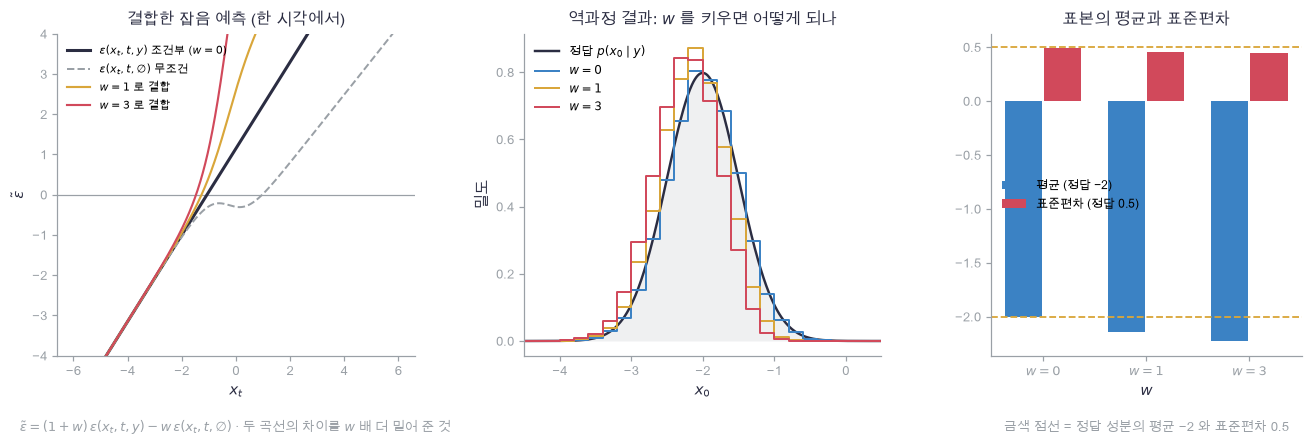

In [59]:
plot_guidance_concept(guide_x, guide_cond, guide_uncond, guide_curves, guide_ws,
                      guide_centers, guide_hists, guide_pdf, guide_means, guide_stds)

🔍 **확인** · 왼쪽에서 검은 곡선(조건부)과 회색 점선(무조건)은 $x_t$가 왼쪽 봉우리 쪽일 때는 거의 겹치고, 오른쪽 봉우리 쪽에서 크게 벌어집니다. 오른쪽 봉우리는 "조건에 맞지 않는 자리"이기 때문입니다. $w$를 키운 곡선(금색·빨강)은 그 벌어진 차이를 그대로 확대합니다.
가운데에서 $w=0$(파랑)은 정답 밀도 $\mathcal N(-2,0.5^2)$와 정확히 겹칩니다. 평균 $-2.00$, 표준편차 $0.488$입니다. **조건부 정답을 알고 있으면 $w=0$으로 충분합니다.** $w$를 키우면 오히려 어긋납니다. $w=3$에서 평균이 $-2.23$으로 왼쪽으로 밀리고 표준편차가 $0.449$로 줄었습니다.
이것이 guidance의 성격입니다. **조건을 더 세게 밀어붙이는 대신 분포를 왜곡합니다.** 그런데도 실전에서 쓰는 이유는, 실제 모델의 조건부 예측이 정확하지 않기 때문입니다. 부정확한 조건부를 무조건 예측과의 차이로 보강하면 "지정한 것이 나올 확률"이 실제로 올라갑니다. 아래 MNIST에서 그 숫자를 봅니다.

아래 구현은 label을 이어 붙인 모델, 결합 한 줄, 그리고 label을 비우는 학습 루프입니다.

> **코드**
>
> - `np.eye(11)[y]`: 11×11 단위행렬에서 `y`번째 행들을 골라 `(N, 11)` one-hot을 만듭니다 (00b번 4절).
> - `dropped[uniform < p_uncond] = 10`: bool 마스크가 True인 자리만 빈 label 번호로 바꿉니다. 원본 `y`는 건드리지 않게 먼저 복사합니다.

In [60]:
def label_onehot(y, n_labels=11):
    """숫자 label 을 one-hot 으로. 번호 10 은 "조건 없음" ∅ 입니다. y: (N,) 정수 0…10 → (N, 11)."""
    return np.eye(n_labels)[np.asarray(y)]


def cond_denoiser(x_t, t, y, p, embed=16):
    """label 을 함께 받는 잡음 예측: U = [x_t, emb(t), onehot(y)] 뒤로는 2절 denoiser_forward 와 같습니다.
    x_t: (N, D), t: (N,) 정수, y: (N,) 정수 0…10 → (eps_hat: (N, D), cache: (U, A))."""
    # 쓰는 것: time_embedding (2절) · label_onehot (4절)
    U = np.concatenate([x_t, time_embedding(t, embed), label_onehot(y)], axis=1)   # (N, D+E+11)
    A = np.tanh(U @ p["W1"] + p["b1"])                               # (N, hidden)
    return A @ p["W2"] + p["b2"], (U, A)

In [61]:
def combine_eps(eps_cond, eps_null, w):
    """guidance 결합 ε̃ = (1 + w) ε_cond − w ε_null. w = 0 이면 조건부 그대로, w 가 클수록 조건 쪽으로 더 밉니다.
    eps_cond, eps_null: (N, D), w: 숫자 → (N, D)."""
    return (1 + w) * eps_cond - w * eps_null


def guided_eps(x_t, t, y, p, w, embed=16):
    """조건부와 무조건 예측을 한 번씩 구해 결합합니다. w = 0 이면 ε̂ 호출이 한 번, 아니면 두 번입니다.
    x_t: (N, D), t: (N,) 정수, y: (N,) 정수 0…9, w: 숫자 → (N, D)."""
    # 쓰는 것: cond_denoiser, combine_eps (4절)
    eps_cond = cond_denoiser(x_t, t, y, p, embed)[0]
    if w == 0:
        return eps_cond
    eps_null = cond_denoiser(x_t, t, np.full(len(x_t), 10), p, embed)[0]   # 빈 label ∅ = 번호 10
    return combine_eps(eps_cond, eps_null, w)

In [62]:
def train_cond_denoiser(X0, y, alpha_bar, steps, seed, hidden=256, embed=16, batch=256, lr=2e-3, p_uncond=0.1):
    """2절 train_denoiser 와 같되, 배치마다 확률 p_uncond 로 label 을 빈 label(10)로 바꿉니다.
    X0: (N, D), y: (N,) 정수 0…9 → (p: 파라미터 사전, history: 스텝별 손실 (steps,))."""
    # 쓰는 것: init_denoiser, denoiser_backward, mse_loss, adam_step (2절) · q_sample (📎 전방 셀) · cond_denoiser (4절)
    last = len(alpha_bar) - 1
    p = init_denoiser(X0.shape[1], embed, hidden, seed, labels=11)    # 입력에 label 칸 11 개를 더 둠
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}
    rng_train = np.random.default_rng(seed + 1)
    history = []
    for step in range(1, steps + 1):
        index = rng_train.choice(len(X0), batch, replace=False)
        X_batch, y_batch = X0[index], y[index].copy()                # copy: 원본 label 을 바꾸지 않게
        y_batch[rng_train.random(batch) < p_uncond] = 10             # 확률 p_uncond 로 조건을 지움
        t = rng_train.integers(1, last + 1, size=batch)
        eps = rng_train.normal(size=X_batch.shape)
        eps_hat, cache = cond_denoiser(q_sample(X_batch, t, eps, alpha_bar), t, y_batch, p, embed)
        loss, d_eps = mse_loss(eps_hat, eps)
        adam_step(p, denoiser_backward(d_eps, cache, p), state, step, lr)
        history.append(loss)
    return p, np.array(history)

In [63]:
# 쓰는 것: init_denoiser, denoiser_backward, mse_loss (2절) · label_onehot, cond_denoiser, combine_eps, guided_eps (4절)
np.testing.assert_allclose(combine_eps(np.array([[0.5]]), np.array([[0.2]]), 0.0), [[0.5]])   # 검산: 손계산 w = 0
np.testing.assert_allclose(combine_eps(np.array([[0.5]]), np.array([[0.2]]), 1.0), [[0.8]])   # 검산: 손계산 2×0.5 − 1×0.2
np.testing.assert_allclose(combine_eps(np.array([[0.5]]), np.array([[0.2]]), 3.0), [[1.4]])   # 검산: 손계산 4×0.5 − 3×0.2
np.testing.assert_allclose(label_onehot([3, 10])[:, [3, 10]], np.eye(2))                      # 검산: 3 번과 빈 label 자리만 1
cond_p_probe = init_denoiser(2, 8, 8, 3541, labels=11)
cond_rng = np.random.default_rng(3542)
cond_xt = cond_rng.normal(size=(5, 2))
cond_eps_true = cond_rng.normal(size=(5, 2))
cond_t = np.array([3, 50, 120, 200, 1])
cond_y = np.array([0, 7, 10, 3, 9])
cond_hat, cond_cache = cond_denoiser(cond_xt, cond_t, cond_y, cond_p_probe, 8)
cond_grads = denoiser_backward(mse_loss(cond_hat, cond_eps_true)[1], cond_cache, cond_p_probe)
np.testing.assert_allclose(guided_eps(cond_xt, cond_t, cond_y, cond_p_probe, 0.0, 8), cond_hat)   # 검산: w = 0 은 조건부 그대로
print("guidance 결합 손계산 0.5 / 0.8 / 1.4 · w = 0 은 조건부와 같음 · label 칸을 더한 입력", cond_cache[0].shape)

guidance 결합 손계산 0.5 / 0.8 / 1.4 · w = 0 은 조건부와 같음 · label 칸을 더한 입력 (5, 21)


In [64]:
# 쓰는 것: numerical_gradient, rel_error (준비 셀) · mse_loss (2절) · cond_denoiser (4절) · cond_p_probe, cond_xt, cond_t, cond_y, cond_eps_true, cond_grads (4절 검산 셀)
def cond_scalar():
    """검사기용: label 을 함께 준 모델의 MSE 손실 (같은 입력·시각·label·정답)."""
    return mse_loss(cond_denoiser(cond_xt, cond_t, cond_y, cond_p_probe, 8)[0], cond_eps_true)[0]


cond_errors = {key: rel_error(cond_grads[key], numerical_gradient(cond_scalar, value)) for key, value in cond_p_probe.items()}
assert max(cond_errors.values()) < 1e-6, "label 을 더해도 네 파라미터의 기울기가 중심차분과 1e−6 안에서 같아야 합니다"
print("label 을 이어 붙인 모델의 gradcheck 최대 상대오차:", max(cond_errors.values()))

label 을 이어 붙인 모델의 gradcheck 최대 상대오차: 8.611123492916967e-10


🔍 **확인** · 결합의 손계산 세 값($0.5$, $0.8$, $1.4$)이 맞고, $w=0$은 조건부 예측과 정확히 같습니다. one-hot을 이어 붙였을 뿐이라 backward는 2절 것을 그대로 쓰고 gradcheck도 통과합니다. **새로 유도할 식이 하나도 없습니다.**

이제 MNIST 좌표에서 label과 함께 학습합니다. 학습용 작은 문제의 결과입니다.

In [65]:
# 쓰는 것: mnist_Z, mnist_y (📎 PCA 셀) · alpha_bar (📎 스케줄 셀) · train_cond_denoiser, cond_denoiser (4절)
cond_p, cond_history = train_cond_denoiser(mnist_Z, mnist_y, alpha_bar, 6000, 355)
cond_probe_Z = mnist_Z[:64]                                          # (64, 32): 같은 좌표에 label 만 바꿔 보기
cond_probe_t = np.full(64, 60)
cond_three = cond_denoiser(cond_probe_Z, cond_probe_t, np.full(64, 3), cond_p)[0]
cond_eight = cond_denoiser(cond_probe_Z, cond_probe_t, np.full(64, 8), cond_p)[0]
cond_null = cond_denoiser(cond_probe_Z, cond_probe_t, np.full(64, 10), cond_p)[0]
cond_label_gap = float(np.mean(np.sum((cond_three - cond_eight) ** 2, axis=1)))
cond_null_gap = float(np.mean(np.sum((cond_three - cond_null) ** 2, axis=1)))
assert cond_label_gap > 0.05, "label 을 3 에서 8 로 바꾸면 예측이 실제로 달라져야 합니다 (모델이 label 을 쓰고 있다는 뜻)"
assert cond_null_gap > 0.05, "조건부 예측과 무조건 예측도 달라야 guidance 가 의미를 가집니다"
print(f"조건부 MSE 손실 {cond_history[:100].mean():.3f} → {cond_history[-300:].mean():.3f}")
print(f"같은 좌표에서 label 3 과 8 의 예측 차이 {cond_label_gap:.4f} · label 3 과 ∅ 의 차이 {cond_null_gap:.4f}")

조건부 MSE 손실 16.177 → 9.123
같은 좌표에서 label 3 과 8 의 예측 차이 3.0897 · label 3 과 ∅ 의 차이 1.9006


In [66]:
# 쓰는 것: beta, alpha_bar (📎 스케줄 셀) · decode_pca, nearest_class, mnist_norm (📎 PCA 셀) · ddpm_sample (2절) · guided_eps (4절) · cond_p (4절 학습 셀)
digit_y = np.tile(np.arange(10), 3)                                  # (30,): 0…9 를 세 줄


def make_guided_fn(y, w):
    """샘플러에 넘길 ε 함수를 만듭니다. 시각 t 마다 지정한 label y 로 guided_eps 를 부릅니다.
    y: (N,) 정수, w: guidance 세기 → eps_fn(x, t)."""
    # 쓰는 것: guided_eps (4절) · cond_p (4절 학습 셀)
    def eps_fn(x, t):
        """x 의 모든 표본에 같은 시각 t 를 주고 결합한 ε̃ 를 냅니다. x: (N, D) → (N, D)."""
        return guided_eps(x, np.full(len(x), t), y, cond_p, w)
    return eps_fn

In [67]:
# 쓰는 것: beta, alpha_bar (📎 스케줄 셀) · decode_pca, nearest_class (📎 PCA 셀) · ddpm_sample (2절) · digit_y, make_guided_fn (4절)
digit_rows, digit_accuracy = [], []
for w in [0.0, 1.0]:
    digit_Z, _ = ddpm_sample(make_guided_fn(digit_y, w), (30, 32), beta, alpha_bar, np.random.default_rng(3560))
    digit_got = nearest_class(digit_Z)                               # (30,): 만든 그림이 어느 숫자로 보이는가
    digit_accuracy.append(float(np.mean(digit_got == digit_y)))
    if w == 1.0:
        digit_rows = [decode_pca(digit_Z[row * 10:(row + 1) * 10]) for row in range(3)]
assert digit_accuracy[1] >= digit_accuracy[0], "guidance 를 켜면 지정한 숫자와 맞는 비율이 줄지 않아야 합니다"
print("지정한 숫자와 맞은 비율 (30장):", "w = 0 →", round(digit_accuracy[0], 3), "· w = 1 →", round(digit_accuracy[1], 3))

지정한 숫자와 맞은 비율 (30장): w = 0 → 0.867 · w = 1 → 1.0


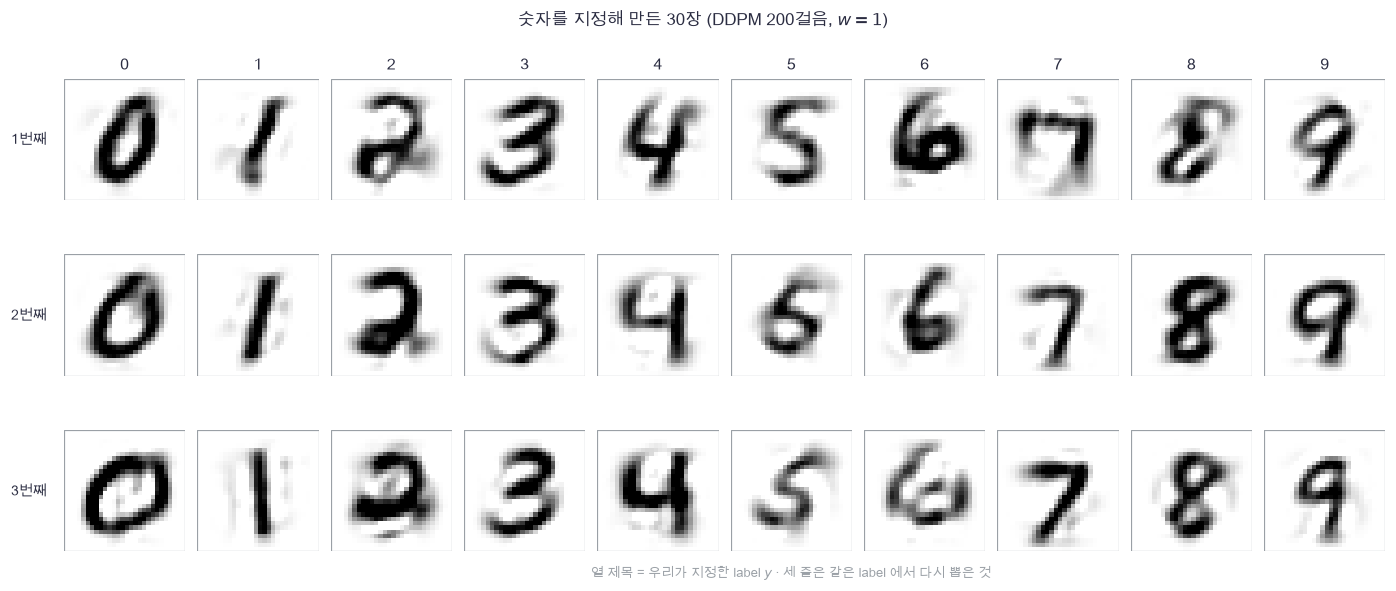

In [68]:
plot_image_rows(digit_rows, ["1번째", "2번째", "3번째"], [str(d) for d in range(10)],
                "숫자를 지정해 만든 30장 (DDPM 200걸음, $w = 1$)", caption="열 제목 = 우리가 지정한 label $y$ · 세 줄은 같은 label 에서 다시 뽑은 것")

In [69]:
# 쓰는 것: beta, alpha_bar (📎 스케줄 셀) · decode_pca, mnist_norm (📎 PCA 셀) · ddpm_sample (2절) · make_guided_fn (4절)
strength_ws = [0.0, 1.0, 3.0]
strength_y = np.full(8, 3)                                           # (8,): 여덟 장 모두 "3 을 그려라"
strength_rows, strength_norms = [], []
for w in strength_ws:
    strength_Z, _ = ddpm_sample(make_guided_fn(strength_y, w), (8, 32), beta, alpha_bar, np.random.default_rng(3561))
    strength_rows.append(decode_pca(strength_Z))
    strength_norms.append(float(np.linalg.norm(strength_Z, axis=1).mean()))
assert strength_norms[2] > strength_norms[0], "w 를 키우면 샘플 좌표가 데이터보다 커지는 쪽으로 밀립니다"
print("w 별 샘플 좌표의 평균 길이:", np.round(strength_norms, 3), "· 데이터", round(mnist_norm, 3))

w 별 샘플 좌표의 평균 길이: [ 5.485  7.32  11.838] · 데이터 5.589


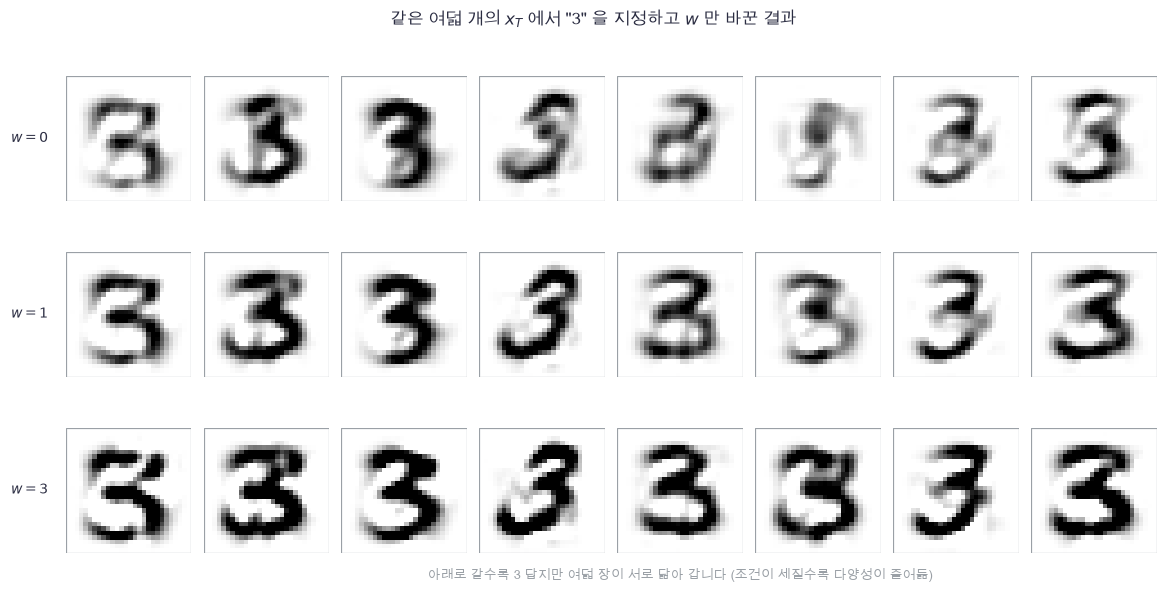

In [70]:
plot_image_rows(strength_rows, [f"$w = {w:g}$" for w in strength_ws], None,
                "같은 여덟 개의 $x_T$ 에서 \"3\" 을 지정하고 $w$ 만 바꾼 결과",
                caption="아래로 갈수록 3 답지만 여덟 장이 서로 닮아 갑니다 (조건이 세질수록 다양성이 줄어듦)")

🔍 **확인** · 30장 격자에서 열 제목이 우리가 지정한 숫자이고, 대부분 그 숫자로 보입니다. $w=0$에서 맞은 비율이 $0.87$, $w=1$에서 $1.00$입니다. 조건부만으로도 꽤 맞지만 guidance가 나머지를 메웁니다.
아래 그림이 대가를 보여 줍니다. $w=0$ 줄은 여덟 장이 서로 다른 3(기울기·굵기가 제각각)이고, $w=3$ 줄은 여덟 장이 비슷하게 굵고 진한 3입니다. 좌표의 평균 길이도 데이터의 $5.59$에서 $w=3$의 $10$ 이상으로 부풀었습니다. **조건은 잘 지켜지지만 표본이 "가장 3다운 3" 쪽으로 몰립니다.**
1차원 실험에서 본 것과 같은 현상입니다. 거기서는 정답 조건부를 알고 있었으므로 $w>0$이 순손해였고, 여기서는 조건부가 부정확하므로 $w=1$ 정도까지는 이득입니다. **$w$는 "조건 충실도"와 "다양성"을 맞바꾸는 손잡이**입니다.

### ✏️ 연습 4 · guidance를 "차이를 $w$배 더하기"로 다시 쓰기

$\tilde\epsilon=(1+w)\epsilon_{\text{cond}}-w\,\epsilon_{\text{null}}$을 풀어 쓰면 $\epsilon_{\text{cond}}+w(\epsilon_{\text{cond}}-\epsilon_{\text{null}})$입니다. 이 형태로 한 줄을 채우세요. 같은 값이지만 "조건이 만드는 차이를 $w$배 더 얹는다"는 뜻이 더 잘 보입니다.

In [71]:

def exercise_guidance_shift(eps_cond, eps_null, w):
    """연습 4: guidance 결합을 "조건부 + w × 차이" 형태로. eps_cond, eps_null: (N, D), w: 숫자 → (N, D)."""
    assert eps_cond.shape == eps_null.shape, "두 예측은 같은 (N, D) 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: eps_tilde = eps_cond + w × (eps_cond − eps_null) (모양 (N, D))
    ### 힌트: 4절 combine_eps 의 (1 + w) ε_cond − w ε_null 를 풀어 쓴 것입니다.
    raise NotImplementedError
    return eps_tilde

In [72]:

def check_guidance_shift(candidate):
    """4절 손계산 세 개와 본문 combine_eps 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: combine_eps (4절)
    hand_cond = np.array([[0.5]])
    hand_null = np.array([[0.2]])
    np.testing.assert_allclose(candidate(hand_cond, hand_null, 0.0), [[0.5]])   # 검산: 손계산 w = 0 이면 조건부 그대로
    np.testing.assert_allclose(candidate(hand_cond, hand_null, 1.0), [[0.8]])   # 검산: 손계산 0.5 + 1×0.3
    np.testing.assert_allclose(candidate(hand_cond, hand_null, 3.0), [[1.4]])   # 검산: 손계산 0.5 + 3×0.3
    cond_c = np.random.default_rng(3578).normal(size=(6, 4))
    null_c = np.random.default_rng(3579).normal(size=(6, 4))
    for w in [0.0, 0.5, 2.0, 7.5]:
        np.testing.assert_allclose(candidate(cond_c, null_c, w), combine_eps(cond_c, null_c, w))   # 검산: 본문 combine_eps 와 같은 값
    print("guidance 결합: 손계산 0.5 / 0.8 / 1.4 · 본문 combine_eps 와 일치합니다.")

run_check(check_guidance_shift, exercise_guidance_shift, hint="eps_tilde = eps_cond + w * (eps_cond - eps_null)")

☐ exercise_guidance_shift: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: eps_tilde = eps_cond + w * (eps_cond - eps_null)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
eps_tilde = eps_cond + w * (eps_cond - eps_null)
```

</details>

## 🔍 5. sampler·걸음 수·guidance를 한 표로

지금까지 손잡이 세 개가 생겼습니다. **sampler**(DDPM / DDIM), **걸음 수 $S$**, **guidance 세기 $w$**입니다. 학습은 한 번뿐이고 이 셋은 생성할 때 고릅니다.
같은 조건부 모델로 200장(숫자 0–9를 20장씩)을 만들어 세 가지를 나란히 잽니다. $\hat\epsilon$ **호출 수**(비용), 지정한 숫자와 **맞은 비율**, 샘플 좌표의 **평균 길이**(데이터와 같은 규모인가)입니다. $w>0$이면 걸음마다 조건부와 무조건을 한 번씩 부르므로 호출 수가 두 배입니다.

In [73]:
# 쓰는 것: T, beta, alpha_bar (📎 스케줄 셀) · nearest_class, mnist_norm (📎 PCA 셀) · ddpm_sample (2절) · ddim_sample (3절) · make_guided_fn (4절)
table_y = np.repeat(np.arange(10), 20)                               # (200,): 숫자마다 20장씩 지정
table_settings = [("DDPM 200, w=0", "ddpm", T, 0.0), ("DDPM 200, w=1", "ddpm", T, 1.0), ("DDPM 200, w=3", "ddpm", T, 3.0),
                  ("DDIM 50, w=0", "ddim", 50, 0.0), ("DDIM 50, w=1", "ddim", 50, 1.0),
                  ("DDIM 20, w=1", "ddim", 20, 1.0), ("DDIM 10, w=1", "ddim", 10, 1.0)]
table_labels, table_calls, table_accuracy, table_norms = [], [], [], []
for name, kind, steps, w in table_settings:
    eps_fn = make_guided_fn(table_y, w)
    if kind == "ddpm":
        table_Z, _ = ddpm_sample(eps_fn, (200, 32), beta, alpha_bar, np.random.default_rng(3570))
    else:
        table_Z = ddim_sample(eps_fn, (200, 32), alpha_bar, np.random.default_rng(3570), steps=steps)
    table_labels.append(name)
    table_calls.append(steps * (2 if w > 0 else 1))                  # w > 0 이면 걸음마다 두 번 부름
    table_accuracy.append(float(np.mean(nearest_class(table_Z) == table_y)))
    table_norms.append(float(np.linalg.norm(table_Z, axis=1).mean()))
for name, calls, accuracy, norm in zip(table_labels, table_calls, table_accuracy, table_norms):
    print(f"{name:16s} 호출 {calls:4d} · 맞은 비율 {accuracy:.3f} · 평균 좌표 길이 {norm:6.2f} (데이터 {mnist_norm:.2f})")

DDPM 200, w=0    호출  200 · 맞은 비율 0.850 · 평균 좌표 길이   5.29 (데이터 5.59)
DDPM 200, w=1    호출  400 · 맞은 비율 0.980 · 평균 좌표 길이   6.74 (데이터 5.59)
DDPM 200, w=3    호출  400 · 맞은 비율 0.965 · 평균 좌표 길이  10.71 (데이터 5.59)
DDIM 50, w=0     호출   50 · 맞은 비율 0.680 · 평균 좌표 길이   5.89 (데이터 5.59)
DDIM 50, w=1     호출  100 · 맞은 비율 0.850 · 평균 좌표 길이   7.78 (데이터 5.59)
DDIM 20, w=1     호출   40 · 맞은 비율 0.850 · 평균 좌표 길이   7.85 (데이터 5.59)
DDIM 10, w=1     호출   20 · 맞은 비율 0.865 · 평균 좌표 길이   8.02 (데이터 5.59)


In [74]:
# 쓰는 것: table_accuracy, table_calls (5절 계산 셀)
assert table_accuracy[1] > table_accuracy[0], "DDPM 에서 w = 1 이 w = 0 보다 조건을 더 잘 지켜야 합니다"
assert table_accuracy[4] > table_accuracy[3], "DDIM 50 에서도 w = 1 이 w = 0 보다 나아야 합니다"
assert table_accuracy[6] > 0.7, "DDIM 10 걸음(호출 20번)으로도 맞은 비율이 0.7 을 넘어야 합니다"
assert table_calls[6] < table_calls[1] / 10, "DDIM 10 의 비용은 DDPM 200 + guidance 의 1/10 아래여야 합니다"
print("w 를 키우면 맞은 비율이 오르고(0 → 1), 걸음 수를 줄이면 비용이 20배 줄어듭니다.")

w 를 키우면 맞은 비율이 오르고(0 → 1), 걸음 수를 줄이면 비용이 20배 줄어듭니다.


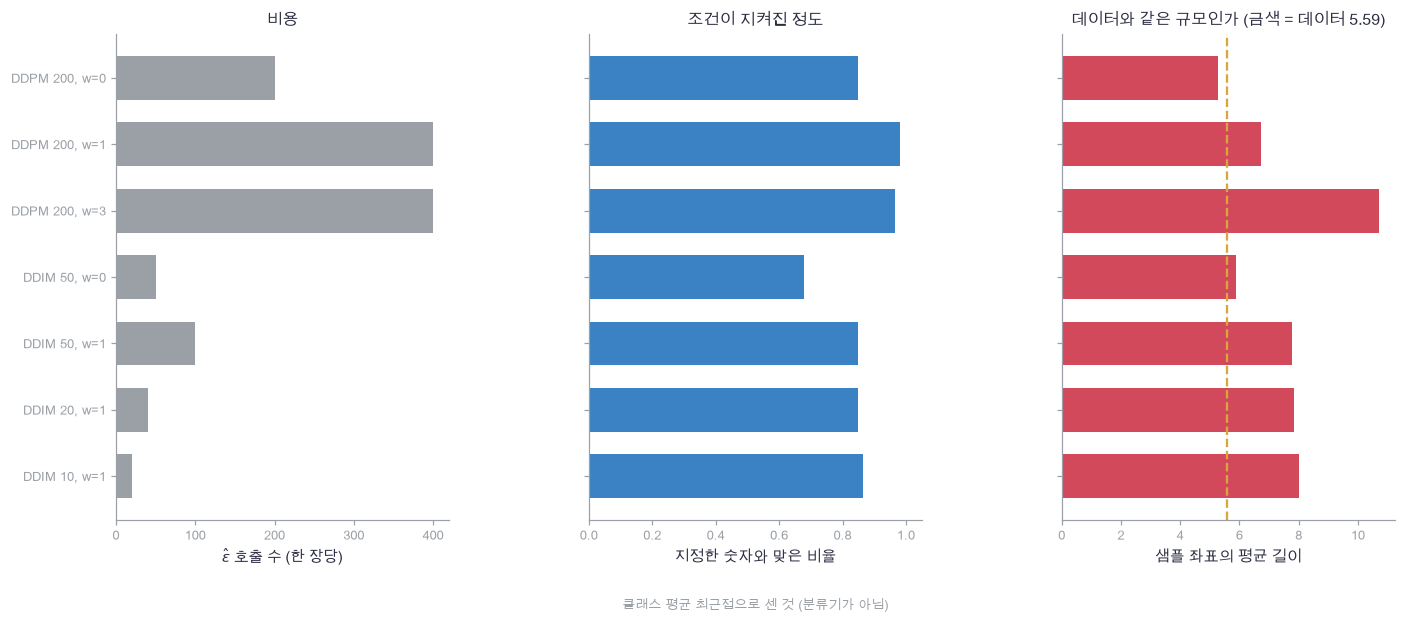

In [75]:
plot_sampler_comparison(table_labels, table_calls, table_accuracy, table_norms, mnist_norm)

🔍 **확인** · 세 막대를 함께 읽습니다.

- **비용**: DDPM 200 + $w>0$은 호출 400번, DDIM 10 + $w=1$은 20번입니다. **20배 차이**입니다.
- **조건 충실도**: 같은 sampler 안에서 $w$를 0에서 1로 올리면 맞은 비율이 뚜렷이 오릅니다($0.85\to0.98$, $0.68\to0.85$). 반면 DDIM 안에서 걸음 수를 $50\to20\to10$으로 줄여도 비율은 거의 그대로입니다. **걸음 수보다 sampler 종류와 guidance가 조건 충실도를 더 크게 움직입니다.**
- **규모**: $w=3$에서 좌표 길이가 데이터의 두 배 가까이 부풉니다. 맞은 비율만 보면 $w=3$이 좋아 보이지만 "데이터와 같은 분포인가"라는 잣대로는 나쁩니다. 어느 잣대를 쓰느냐에 따라 최선이 달라지는 것은 34번 5절에서 본 것과 같은 이야기입니다.

세 손잡이의 좋은 값은 문제마다 다릅니다. 여기서 얻을 것은 "무엇과 무엇을 맞바꾸는지"이고, 이 절충을 하나의 틀로 정리하는 것이 [35b EDM](35b_edm.ipynb)의 주제입니다. 이 표는 학습용 작은 문제(PCA-32 좌표, 은닉 256 MLP, 6,000스텝)의 결과이며 실제 벤치마크가 아닙니다.

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · $\hat x_0$에서 되묻기 평균으로 (1절)

시각 `t`에서 추측한 원본 `x0_hat`과 지금 자리 `x_t`로 되묻기 평균 $\tilde\mu_t=c_0(t)\hat x_0+c_t(t)x_t$를 만드는 한 줄을 채우세요. 두 계수는 써 두었습니다. 1절의 절 연습이 $\hat\epsilon$ 쪽 식이었다면, 이쪽은 $\hat x_0$ 쪽 식입니다. 같은 값이 나와야 합니다.

In [76]:
def exercise_posterior_from_x0(x_t, x0_hat, t, beta_values, alpha_bar_values):
    """연습 A: 되묻기 평균 μ̃_t = c₀(t) x̂₀ + c_t(t) x_t (34번 2절). x_t, x0_hat: (N, D), t: 정수 → (N, D)."""
    assert x_t.shape == x0_hat.shape, "x_t 와 x̂₀ 는 같은 (N, D) 모양이어야 합니다"
    ab, ab_prev = alpha_bar_values[t], alpha_bar_values[t - 1]        # ᾱ_t 와 ᾱ_{t−1}
    c0 = np.sqrt(ab_prev) * beta_values[t] / (1 - ab)                 # √ᾱ_{t−1} β_t / (1 − ᾱ_t)
    ct = np.sqrt(1 - beta_values[t]) * (1 - ab_prev) / (1 - ab)       # √α_t (1 − ᾱ_{t−1}) / (1 − ᾱ_t)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: mu = c0 × x0_hat + ct × x_t (모양 (N, D))
    ### 힌트: 1절의 μ_θ = c₀ x̂₀ + c_t x_t 한 줄입니다. c0, ct 는 숫자라 브로드캐스팅으로 곱해집니다.
    raise NotImplementedError
    return mu

In [77]:
def check_posterior_from_x0(candidate):
    """1절 손계산(장난감 스케줄 t = 2)과 본문 ddpm_mean 으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: toy_beta, toy_alpha_bar (1절 검산 셀) · beta, alpha_bar (📎 스케줄 셀) · ddpm_mean (1절)
    hand_got = candidate(np.array([[1.1]]), np.array([[0.984558]]), 2, toy_beta, toy_alpha_bar)
    np.testing.assert_allclose(hand_got, [[1.018549]], atol=1e-6)    # 검산: 손계산 0.677631×0.984558 + 0.319438×1.1
    x_c = np.random.default_rng(3581).normal(size=(6, 3))
    eps_c = np.random.default_rng(3582).normal(size=(6, 3))
    for t in [1, 40, 137, 200]:
        x0_c = (x_c - np.sqrt(1 - alpha_bar[t]) * eps_c) / np.sqrt(alpha_bar[t])   # 34번 3절의 한 줄
        got = candidate(x_c, x0_c, t, beta, alpha_bar)
        np.testing.assert_allclose(got, ddpm_mean(x_c, t, eps_c, beta, alpha_bar))   # 검산: ε̂ 쪽 식과 같은 값
    print("되묻기 평균: 손계산·본문 ddpm_mean 과 일치합니다.")

run_check(check_posterior_from_x0, exercise_posterior_from_x0, hint="mu = c0 * x0_hat + ct * x_t")

☐ exercise_posterior_from_x0: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: mu = c0 * x0_hat + ct * x_t


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
mu = c0 * x0_hat + ct * x_t
```

</details>

### ✏️ 연습 B · 역과정 반복문 (2절)

출발점 `x_T`와 $\epsilon$ 함수 `eps_fn`에서 $t=T$부터 1까지 `ddpm_step`을 반복하는 for 문을 채우세요. 이 세 줄이 diffusion 생성의 전부입니다.

In [78]:
def exercise_reverse_loop(eps_fn, x_T, beta_values, alpha_bar_values, rng):
    """연습 B: 역과정 루프. eps_fn(x, t) → (N, D), x_T: (N, D) → x_0: (N, D)."""
    x = np.array(x_T, dtype=float)                                   # 넘겨받은 배열을 바꾸지 않게 복사
    last = len(alpha_bar_values) - 1                                 # T (스케줄 배열의 마지막 번호)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: t 를 last 부터 1 까지 내려가며 x = ddpm_step(x, t, eps_fn(x, t), rng, beta_values, alpha_bar_values)
    ### 힌트: range(last, 0, -1) 이 T, T−1, …, 1 입니다. 2절 ddpm_sample 의 for 문과 같습니다.
    raise NotImplementedError
    return x

In [79]:
def check_reverse_loop(candidate):
    """걸음이 하나뿐인 손계산과, 본문 ddpm_step 을 T…1 로 이어 붙인 값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: beta, alpha_bar (📎 스케줄 셀) · ddpm_step (1절) · mix_eps_fn (2절)
    def constant_eps(x, t):
        """검사기용: 언제나 0.5 를 내는 가짜 ε 함수. x: (N, D) → (N, D)."""
        return np.full_like(x, 0.5)

    one_beta = np.array([0.0, 0.36])                                 # 걸음이 하나뿐인 스케줄: ᾱ₁ = 0.64
    one_bar = np.cumprod(1 - one_beta)
    one_got = candidate(constant_eps, np.array([[1.1]]), one_beta, one_bar, np.random.default_rng(0))
    np.testing.assert_allclose(one_got, [[1.0]])                     # 검산: 손계산 (1.1 − 0.6×0.5)/0.8, 마지막 걸음이라 잡음 없음
    start = np.random.default_rng(3583).normal(size=(300, 1))        # (300, 1): 같은 x_T
    got = candidate(mix_eps_fn, start, beta, alpha_bar, np.random.default_rng(3584))
    want = start.copy()                                              # 기준값: 같은 x_T 에서 손으로 이어 붙인 역과정
    rng_want = np.random.default_rng(3584)                           # got 과 같은 seed 라 뽑는 잡음까지 같습니다
    for t in range(len(alpha_bar) - 1, 0, -1):                       # T, T−1, …, 1
        want = ddpm_step(want, t, mix_eps_fn(want, t), rng_want, beta, alpha_bar)
    assert got.shape == (300, 1), f"x₀ 는 x_T 와 같은 (300, 1) 이어야 하는데 {got.shape} 입니다"
    np.testing.assert_allclose(got, want)                            # 검산: 본문 ddpm_step 을 T…1 로 이어 붙인 것과 같음 (t 를 거꾸로 올라가면 여기서 걸립니다)
    print("역과정 반복문: 손계산·본문 ddpm_step 을 T…1 로 이어 붙인 값과 일치합니다.")

run_check(check_reverse_loop, exercise_reverse_loop,
          hint="for t in range(last, 0, -1): x = ddpm_step(x, t, eps_fn(x, t), rng, beta_values, alpha_bar_values)")

☐ exercise_reverse_loop: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: for t in range(last, 0, -1): x = ddpm_step(x, t, eps_fn(x, t), rng, beta_values, alpha_bar_values)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
for t in range(last, 0, -1):
    x = ddpm_step(x, t, eps_fn(x, t), rng, beta_values, alpha_bar_values)
```

</details>

### ✏️ 연습 C · 부분 시간열 만들기 (3절)

$T$부터 1까지에서 고르게 `steps`개를 골라 **내림차순** 정수 배열을 만드는 한 줄을 채우세요. 이 배열의 길이가 곧 $\hat\epsilon$ 호출 수입니다.

In [80]:
def exercise_sub_times(last, steps):
    """연습 C: 고르게 고른 내림차순 부분 시간열. last: T, steps: 걸음 수 ≥ 2 → 내림차순 정수 배열 (길이는 steps 이하)."""
    assert 2 <= steps <= last, "걸음 수는 2 이상 T 이하여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: times = last 와 1 사이를 고르게 나눈 steps 개를 반올림해 정수로 바꾸고, 중복을 없앤 뒤 내림차순으로
    ### 힌트: np.linspace(last, 1, steps).round().astype(int) 뒤에 np.unique(...)[::-1] 입니다 (3절 uniform_times).
    raise NotImplementedError
    return times

In [81]:
def check_sub_times(candidate):
    """손계산 두 경우와 본문 uniform_times, ddim_sample 이 쓰는 성질로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: T (📎 스케줄 셀) · uniform_times (3절)
    np.testing.assert_allclose(candidate(10, 10), np.arange(10, 0, -1))        # 검산: steps = T 면 전체 시간열
    np.testing.assert_allclose(candidate(200, 5), [200, 150, 100, 51, 1])      # 검산: linspace(200, 1, 5) = 200, 150.25, 100.5, 50.75, 1 을 반올림
    for steps in [10, 20, 50, 200]:
        np.testing.assert_allclose(candidate(T, steps), uniform_times(T, steps))   # 검산: 본문 uniform_times 와 같음
    made = candidate(T, 17)
    assert made[0] == T, "부분 시간열은 T 에서 시작해야 합니다"
    assert made[-1] == 1, "부분 시간열은 1 에서 끝나야 합니다"
    assert np.all(np.diff(made) < 0), "부분 시간열은 내림차순이어야 합니다"
    print("부분 시간열: 손계산·본문 uniform_times 와 일치합니다.")

run_check(check_sub_times, exercise_sub_times, hint="times = np.unique(np.linspace(last, 1, steps).round().astype(int))[::-1]")

☐ exercise_sub_times: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: times = np.unique(np.linspace(last, 1, steps).round().astype(int))[::-1]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
times = np.unique(np.linspace(last, 1, steps).round().astype(int))[::-1]
```

</details>

### ✏️ 연습 D · 학습 중 label 비우기 (4절)

배치의 label `y`와 0–1 난수 `uniform`에서, 확률 `p_uncond`로 label을 빈 label(번호 10)로 바꾸는 한 줄을 채우세요. 이 한 줄이 없으면 모델은 무조건 예측 $\hat\epsilon(x_t,t,\varnothing)$을 배우지 못하고 guidance도 쓸 수 없습니다.

In [82]:
def exercise_drop_labels(y, uniform, p_uncond, null_label=10):
    """연습 D: 확률 p_uncond 로 label 을 비웁니다. y: (B,) 정수, uniform: (B,) 0–1 난수 → (B,) 정수."""
    assert len(y) == len(uniform), "label 수와 난수 수가 같아야 합니다"
    dropped = np.array(y)                                            # 원본 y 를 바꾸지 않게 복사
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: uniform < p_uncond 인 자리의 label 을 null_label 로 바꾸기
    ### 힌트: 4절 train_cond_denoiser 의 한 줄입니다. bool 마스크로 고른 자리에 값을 넣습니다.
    raise NotImplementedError
    return dropped

In [83]:
def check_drop_labels(candidate):
    """손계산 네 개와 비율, 원본 보존으로 검사합니다. 통과하면 메시지를 출력합니다."""
    hand_y = np.array([3, 7, 1, 9])
    hand_u = np.array([0.05, 0.50, 0.02, 0.90])
    np.testing.assert_allclose(candidate(hand_y, hand_u, 0.1), [10, 7, 10, 9])   # 검산: 0.05 와 0.02 만 0.1 보다 작음
    np.testing.assert_allclose(hand_y, [3, 7, 1, 9])                             # 검산: 원본 label 은 그대로
    np.testing.assert_allclose(candidate(hand_y, hand_u, 0.0), hand_y)           # 검산: p_uncond = 0 이면 아무것도 지우지 않음
    many_y = np.random.default_rng(3585).integers(0, 10, size=20000)
    many_u = np.random.default_rng(3586).random(20000)
    fraction = float(np.mean(candidate(many_y, many_u, 0.1) == 10))
    assert abs(fraction - 0.1) < 0.01, f"비운 비율 {fraction:.3f} 이 p_uncond = 0.1 과 0.01 안에서 같아야 합니다"
    print("label 비우기: 손계산 네 개·비율 0.1 과 일치합니다.")

run_check(check_drop_labels, exercise_drop_labels, hint="dropped[uniform < p_uncond] = null_label")

☐ exercise_drop_labels: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dropped[uniform < p_uncond] = null_label


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dropped[uniform < p_uncond] = null_label
```

</details>

### 🔍 완성 예제 · 걸음의 분산을 $\tilde\beta_t$ 대신 $\beta_t$로 두면

1절에서 $\sigma_t^2$의 두 선택을 보았습니다. $\tilde\beta_t$는 "$x_0$를 알 때의 불확실성", $\beta_t$는 "앞으로 한 걸음 갈 때의 불확실성"이고 $\tilde\beta_t\le\beta_t$입니다. DDPM 논문은 둘 다 비슷하게 동작한다고 보고했습니다. 정말 그런지 같은 정답 $\epsilon^*$로 확인합니다.
바뀌는 것은 `ddpm_step`의 `variance` 인자 하나뿐이고 나머지 코드는 한 줄도 바뀌지 않습니다. 20,000개 표본의 TV 거리·평균·표준편차·봉우리 비율을 비교하고, MNIST 좌표에서도 샘플 길이를 재 봅니다.

In [84]:
# 쓰는 것: T, beta, alpha_bar (📎 스케줄 셀) · MIX_PI, MIX_MU, mix_logpdf, mix_responsibility (📎 혼합 셀) · back_edges, back_centers, back_hists (1-1절) · ddpm_sample, mix_eps_fn (2절)
variant_hists, variant_stats = [], []                                # 분산 선택마다 히스토그램과 통계
for choice in ["beta_tilde", "beta"]:
    variant_Z, _ = ddpm_sample(mix_eps_fn, (20000, 1), beta, alpha_bar, np.random.default_rng(3590), variance=choice)
    counts = np.histogram(variant_Z[:, 0], back_edges)[0] / (20000 * 0.2)
    variant_hists.append(counts)
    variant_stats.append((0.5 * float(np.sum(np.abs(counts - np.exp(mix_logpdf(back_centers))))) * 0.2,
                          float(variant_Z.mean()), float(variant_Z.std()),
                          float(mix_responsibility(variant_Z[:, 0]).mean(axis=0)[1])))
assert variant_stats[1][0] < 0.05, "β_t 로 두어도 TV 거리가 0.05 아래여야 합니다 (두 선택 모두 쓸 만함)"
assert variant_stats[1][2] > variant_stats[0][2], "β_t 는 β̃_t 보다 잡음을 더 더하므로 표본이 조금 더 퍼져야 합니다"
print("(TV 거리, 평균, 표준편차, 오른쪽 봉우리 비율) · 참값 평균 0.8, 비율 0.7")
print("  σ² = β̃_t:", np.round(variant_stats[0], 4))
print("  σ² = β_t :", np.round(variant_stats[1], 4))

(TV 거리, 평균, 표준편차, 오른쪽 봉우리 비율) · 참값 평균 0.8, 비율 0.7
  σ² = β̃_t: [0.0187 0.7796 2.0211 0.697 ]
  σ² = β_t : [0.0171 0.779  2.0288 0.6968]


In [85]:
# 쓰는 것: mnist_norm (📎 PCA 셀) · beta, alpha_bar (📎 스케줄 셀) · nearest_class (📎 PCA 셀) · ddpm_sample, gen_eps (2절)
variant_norms, variant_kinds = [], []
for choice in ["beta_tilde", "beta"]:
    variant_mnist, _ = ddpm_sample(gen_eps, (64, 32), beta, alpha_bar, np.random.default_rng(3591), variance=choice)
    variant_norms.append(float(np.linalg.norm(variant_mnist, axis=1).mean()))
    variant_kinds.append(int(np.count_nonzero(np.bincount(nearest_class(variant_mnist), minlength=10))))
print("MNIST 좌표 64장 · 평균 좌표 길이:", np.round(variant_norms, 3), "(데이터", round(mnist_norm, 3), ")")
print("서로 다른 숫자 가짓수:", variant_kinds)

MNIST 좌표 64장 · 평균 좌표 길이: [5.096 5.145] (데이터 5.589 )
서로 다른 숫자 가짓수: [10, 10]


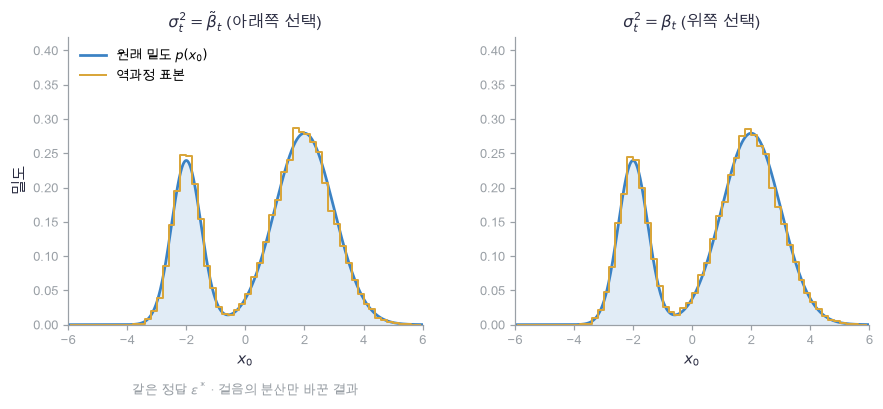

In [86]:
plot_reverse_histograms(back_x, back_pdf, back_centers, variant_hists,
                        ["$\\sigma_t^2 = \\tilde\\beta_t$ (아래쪽 선택)", "$\\sigma_t^2 = \\beta_t$ (위쪽 선택)"],
                        "같은 정답 $\\epsilon^*$ · 걸음의 분산만 바꾼 결과")

🔍 **확인** · 두 히스토그램이 거의 같습니다. TV 거리도 비슷하고, $\beta_t$ 쪽이 표준편차가 아주 조금 큽니다. 걸음마다 더 많은 잡음을 더했으니 당연합니다. MNIST 좌표에서도 평균 길이와 나온 숫자 가짓수가 비슷합니다.
결론은 **이 선택이 결과를 크게 바꾸지 않는다**는 것입니다. 200걸음에 걸쳐 조금씩 다른 잡음을 더해도 마지막 분포는 비슷한 곳으로 모입니다. DDPM 논문이 두 선택을 모두 보고한 이유입니다.
반대로 1-1절에서 본 **스케줄의 $\bar\alpha_T$**는 결과를 크게 바꿨습니다. 같은 "잡음을 얼마나 더하나"라는 손잡이라도, 출발점을 어긋나게 만드는 것과 걸음마다의 세부를 바꾸는 것은 무게가 다릅니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 역과정 한 걸음이 34번 2절의 되묻기와 어떻게 이어지는지, $x_0$를 모르는데 왜 되묻기 식을 쓸 수 있는지 말할 수 있나요? → 1절
- **수식:** $\mu_\theta$를 $\hat\epsilon$ 쪽 식과 $\hat x_0$ 쪽 식으로 각각 쓰고, 둘이 같음을 계수를 정리해 보일 수 있나요? 그리고 DDIM의 $\sigma$에서 $\eta=1,\ s=t-1$이면 $\tilde\beta_t$가 나오는 것을 확인할 수 있나요? → 1·3절
- **구현:** 잡음에서 출발해 $T$걸음 되돌아오는 루프, 부분 시간열을 따라 걷는 DDIM 루프, guidance 결합 한 줄을 직접 쓸 수 있나요? → 2·3·4절
- **변형:** 걸음 수 $S$와 guidance $w$를 바꾸면 비용·조건 충실도·다양성이 각각 어떻게 움직이는지, $w$를 너무 키우면 무엇이 나빠지는지 설명할 수 있나요? → 3·4절

다음은 [35b EDM](35b_edm.ipynb)입니다. 지금까지 따로 고른 스케줄·손실 가중치·sampler를 "잡음 크기 $\sigma$ 하나"로 다시 적어, 무엇이 본질이고 무엇이 관례였는지 정리합니다.

📎 [Ho 등, 2020 (DDPM)](https://arxiv.org/abs/2006.11239)이 이 노트북 1·2절의 역과정과 두 분산 선택을, [Song 등, 2020 (DDIM)](https://arxiv.org/abs/2010.02502)이 3절의 결정적 걸음과 부분 시간열을, [Ho·Salimans, 2022](https://arxiv.org/abs/2207.12598)가 4절의 classifier-free guidance를 제안했습니다. 이 노트북의 혼합 예제와 32차원 좌표 모델은 설명을 위해 새로 구성한 것이며 원논문의 재현 실험은 아닙니다.